In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qutip import *
# import rydsim
from math import * 
from tqdm import tqdm   
from scipy import integrate 
import scipy.constants 
from scipy.constants import Planck,epsilon_0,Boltzmann 
import pandas as pd

# Define path to ARC root directory (for loading data)
import sys, os
# rootDir = 'd:\\Heidelberg\\Calculation\\Python\\arc_python27_v1_3\\arc\\' # e.g. '/Users/Username/Desktop/ARC-Alkali-Rydberg-Calculator'
# sys.path.append(rootDir)
# os.chdir(rootDir)

from arc import *                 #Import ARC (Alkali Rydberg Calculator)
atom = Rubidium85()

In [2]:
# States 2-photon, 32D5/2
[n1,l1,j1,mj1] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n2,l2,j2,mj2] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n3,l3,j3,mj3] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n4,l4,j4,mj4] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power12 = 10.e-9 # 10nW
power23 = 60.e-3 # 60mW
power34 = 10e-3 # 10mW

# Beam waist (m)
waist12 = (150.e-6)/2  
waist23 = (150.e-6)/2
waist34 = 0.02

# Transition wavelength (m)
lambda12 = atom.getTransitionWavelength(n1,l1,j1,n2,l2,j2) # 780-nm laser
lambda23 = atom.getTransitionWavelength(n2,l2,j2,n3,l3,j3) # 480-nm laser
lambda34 = atom.getTransitionWavelength(n3,l3,j3,n4,l4,j4) # RF

# Transition frequency (Hz)
freq12 = atom.getTransitionFrequency(n1,l1,j1,n2,l2,j2) # 780-nm laser
freq23 = atom.getTransitionFrequency(n2,l2,j2,n3,l3,j3) # 480-nm laser
freq34 = atom.getTransitionFrequency(n3,l3,j3,n4,l4,j4) # RF

# Dipole moment matrix element
q=0 # linear polarization
dipmat12 = atom.getDipoleMatrixElement(n1,l1,j1,mj1,n2,l2,j2,mj2,q)
dipmat23 = atom.getDipoleMatrixElement(n2,l2,j2,mj2,n3,l3,j3,mj3,q)
dipmat34 = atom.getDipoleMatrixElement(n3,l3,j3,mj3,n4,l4,j4,mj4,q)

# Transition detuning (Hz)
delta12 = 0
delta23 = 0
delta34 = 0

# Rabi Frequency (2pi is already included)
rabi12 = atom.getRabiFrequency(n1,l1,j1,mj1,n2,l2,j2,q,power12,waist12)/(2*pi)*1e-6 # unit of 2pi MHz
rabi23 = atom.getRabiFrequency(n2,l2,j2,mj2,n3,l3,j3,q,power23,waist23)/(2*pi)*1e-6 # unit of 2pi MHz
rabi34 = atom.getRabiFrequency(n3,l3,j3,mj2,n4,l4,j4,q,power34,waist34)/(2*pi)*1e-6 # unit of 2pi MHz

In [3]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin

n = [0 for i in range(4)]
l = [0 for i in range(4)]
j = [0 for i in range(4)]
mj = [0 for i in range(4)]
[n[0],l[0],j[0],mj[0]] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n[1],l[1],j[1],mj[1]] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n[2],l[2],j[2],mj[2]] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n[3],l[3],j[3],mj[3]] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power = [10.e-9,60.e-3,10e-3]

# Beam waist (m)
waist=[(150.e-6)/2,(150.e-6)/2,0.025]

# Wavelength (m)
lambda_trans = [atom.getTransitionWavelength(n[i],l[i],j[i],n[i+1],l[i+1],j[i+1]) for i in range(len(n)-1)]
if debug: print('Wavelength (m)',lambda_trans)

# Rabi Frequency (Hz)
Rabifreq = [atom.getRabiFrequency(n[i],l[i],j[i],mj[i],n[i+1],l[i+1],j[i+1],q,power[i],waist[i])/(2*pi) for i in range(len(n)-1)]
if debug: print('Rabi Frequency (Hz)',Rabifreq)

# Decay rate (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,len(n))]
if debug: print('Gamma (Hz): ',Gamma)

# Different in transition frequency comparing to ground state (Hz)
def Hdiag(n,l,j):
    Estate = []
    statelist = []
    for i in range(len(n)):
        transition = atom.getTransitionFrequency(n[0],l[0],j[0],n[i],l[i],j[i])*2*pi        
        statelist.append([n[i],l[i],j[i]])
        Estate.append(transition)    
    nstate = len(Estate)
    Hstate = np.diag(Estate)
    return nstate, statelist, Hstate
if debug: print(Hdiag(n,l,j)[2])

Wavelength (m) [7.802415056628226e-07, 4.821001280638597e-07, 0.002297133888579615]
Rabi Frequency (Hz) [911940.821030698, 12574646.13352145, 509420590.15879244]
Gamma (Hz):  [0, 6065897.146680555, 8520.896529086971, 5370.248302059757]
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.41419042e+15 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.32136957e+15 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 6.32218957e+15]]


In [4]:
# Define the levels and atomic projection operators
one, two, three, four = [basis(4,i) for i in range(4)]

In [5]:
# Define the levels and atomic projection operators
sig_11 = one * one.dag()
sig_22 = two * two.dag()
sig_33 = three * three.dag() 
sig_44 = four * four.dag() 
sig_12 = one * two.dag()  
sig_13 = one * three.dag() 
sig_14 = one * four.dag() 
sig_23 = two * three.dag()  
sig_24 = two * four.dag()
sig_34 = three * four.dag()

In [6]:
gamma_diag = np.diag(Gamma);gamma_diag

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 6.06589715e+06, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 8.52089653e+03, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.37024830e+03]])

In [7]:
#define number of state 
n_state = int(4) 
gamma_off = [[0.5*(gamma_diag[i][i]+gamma_diag[j][j]) if i != j else 0 for j in range(n_state)] for i in range(n_state)];gamma_off

[[0, 3032948.5733402777, 4260.4482645434855, 2685.1241510298787],
 [3032948.5733402777, 0, 3037209.021604821, 3035633.6974913077],
 [4260.4482645434855, 3037209.021604821, 0, 6945.572415573364],
 [2685.1241510298787, 3035633.6974913077, 6945.572415573364, 0]]

In [8]:
gamma = (gamma_diag+gamma_off) ;gamma

array([[0.00000000e+00, 3.03294857e+06, 4.26044826e+03, 2.68512415e+03],
       [3.03294857e+06, 6.06589715e+06, 3.03720902e+06, 3.03563370e+06],
       [4.26044826e+03, 3.03720902e+06, 8.52089653e+03, 6.94557242e+03],
       [2.68512415e+03, 3.03563370e+06, 6.94557242e+03, 5.37024830e+03]])

In [9]:
#collapse operators 
c_12 = -np.sqrt(gamma[0][1])*sig_12 # 1-2 coherence decay  
#c_21 = -np.sqrt(gamma[0][1])*sig_21
c_13 = -np.sqrt(gamma[0][2])*sig_13 # 1-3 coherence decay  
#c_31 = -np.sqrt(gamma[0][2])*sig_31 # 1-3 coherence decay  
c_14 = -np.sqrt(gamma[0][3])*sig_14  # 1-4 coherence decay  
#c_41 = -np.sqrt(gamma[0][3])*sig_41  # 1-4 coherence decay   
c_23 = -np.sqrt(gamma[1][2])*sig_23 # 2-3 coherence decay 
#c_32 = -np.sqrt(gamma[1][2])*sig_32 # 2-3 coherence decay 
c_24 = -np.sqrt(gamma[1][3])*sig_24  # 2-4 coherence decay  
#c_42 = -np.sqrt(gamma[1][3])*sig_42  # 2-4 coherence decay  
c_34 = -np.sqrt(gamma[2][3])*sig_34  
#c_43 = -np.sqrt(gamma[2][3])*sig_43
#transitions decay rate  
c_11 = np.sqrt(gamma[1][1])*sig_22
c_22 = np.sqrt(gamma[2][2])*sig_33 -  np.sqrt(gamma[1][1])*sig_22
c_33 = np.sqrt(gamma[3][3])*sig_44 -  np.sqrt(gamma[2][2])*sig_33
c_44 = -np.sqrt(gamma[3][3])*sig_44 
#check define collapse operator
collapse = [c_11,c_22,c_33,c_44,c_12,c_13,c_14,c_23,c_24,c_34]

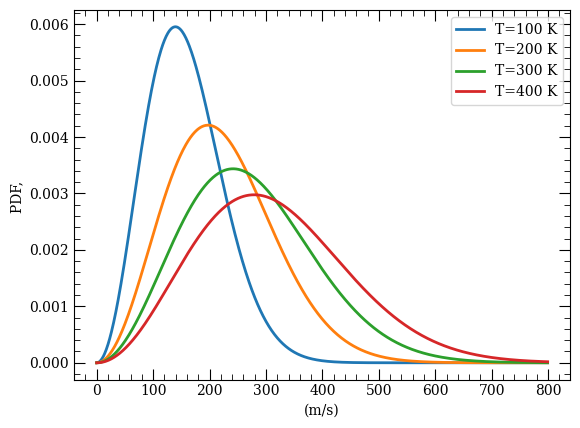

In [10]:
def MB_speed(v,m,T):
    """ Maxwell-Boltzmann speed distribution for speeds """
    kB = 1.38e-23
    return (m/(2*np.pi*kB*T))**1.5 * 4*np.pi * v**2 * np.exp(-m*v**2/(2*kB*T))

fig = plt.figure()
ax = fig.add_subplot(111)

v = np.arange(0,800,1)
amu = 1.66e-27
mass = 85.4678*amu

for T in [100,200,300,400]:
    fv = MB_speed(v,mass,T)
    ax.plot(v,fv,label='T='+str(T)+' K',lw=2)

ax.legend(loc=0)
ax.set_xlabel('(m/s)')
ax.set_ylabel('PDF, ')
plt.draw()

In [11]:
u = sqrt(2*Boltzmann*temperature/mass);u 
u = round(u, 2)
v_list = np.arange(-u/2,u/2,1)  
print(u,v_list)

241.64 [-120.82 -119.82 -118.82 -117.82 -116.82 -115.82 -114.82 -113.82 -112.82
 -111.82 -110.82 -109.82 -108.82 -107.82 -106.82 -105.82 -104.82 -103.82
 -102.82 -101.82 -100.82  -99.82  -98.82  -97.82  -96.82  -95.82  -94.82
  -93.82  -92.82  -91.82  -90.82  -89.82  -88.82  -87.82  -86.82  -85.82
  -84.82  -83.82  -82.82  -81.82  -80.82  -79.82  -78.82  -77.82  -76.82
  -75.82  -74.82  -73.82  -72.82  -71.82  -70.82  -69.82  -68.82  -67.82
  -66.82  -65.82  -64.82  -63.82  -62.82  -61.82  -60.82  -59.82  -58.82
  -57.82  -56.82  -55.82  -54.82  -53.82  -52.82  -51.82  -50.82  -49.82
  -48.82  -47.82  -46.82  -45.82  -44.82  -43.82  -42.82  -41.82  -40.82
  -39.82  -38.82  -37.82  -36.82  -35.82  -34.82  -33.82  -32.82  -31.82
  -30.82  -29.82  -28.82  -27.82  -26.82  -25.82  -24.82  -23.82  -22.82
  -21.82  -20.82  -19.82  -18.82  -17.82  -16.82  -15.82  -14.82  -13.82
  -12.82  -11.82  -10.82   -9.82   -8.82   -7.82   -6.82   -5.82   -4.82
   -3.82   -2.82   -1.82   -0.82    0.18    

In [13]:
2*v*1E-6 /lambda_trans[0]

array([   0.        ,    2.56330891,    5.12661781,    7.68992672,
         10.25323562,   12.81654453,   15.37985343,   17.94316234,
         20.50647124,   23.06978015,   25.63308906,   28.19639796,
         30.75970687,   33.32301577,   35.88632468,   38.44963358,
         41.01294249,   43.5762514 ,   46.1395603 ,   48.70286921,
         51.26617811,   53.82948702,   56.39279592,   58.95610483,
         61.51941373,   64.08272264,   66.64603155,   69.20934045,
         71.77264936,   74.33595826,   76.89926717,   79.46257607,
         82.02588498,   84.58919389,   87.15250279,   89.7158117 ,
         92.2791206 ,   94.84242951,   97.40573841,   99.96904732,
        102.53235622,  105.09566513,  107.65897404,  110.22228294,
        112.78559185,  115.34890075,  117.91220966,  120.47551856,
        123.03882747,  125.60213638,  128.16544528,  130.72875419,
        133.29206309,  135.855372  ,  138.4186809 ,  140.98198981,
        143.54529871,  146.10860762,  148.67191653,  151.23522

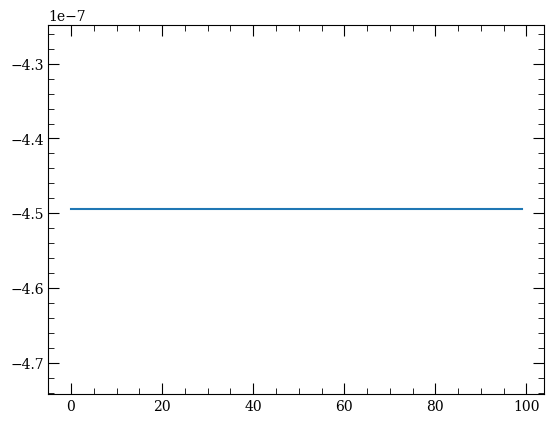

In [181]:
plt.plot(rho_delta)

In [12]:
#EIT probe detunings
# create list of delta_p values
deltalist = np.linspace(-1000,1000,400)
# empty list to save results
chi = [] # susceptibility

In [13]:
#define Rabies frequency 
#E=1E3
deltaC = 0 # coupling field detuning  
deltaC_list = [0.1*i for i in range(0,6)]
deltaRF = 0 
#For omegaP and OmagaC is 1 MHz
omegaP = 1E6 # Rabi freq. for probe
omegaC = 100E6 # Rabi freq. for control  
omega_RF_list = [(2**i)*1e6 for i in range(8)]
deltaP0 = 1E6 
omega = 0

In [14]:
chi_omegaRF_list=[] 
deltaP =0 
deltaC = 0
for omegaP in tqdm(omega_RF_list) : 
    chi=[]
    for deltaC in deltalist:
        H = 1/2*Qobj([[0,omegaP,0,0],[omegaP,-2*deltaP*10**6,omegaC,0]
               ,[0,omegaC,-2*(deltaP+deltaC)*10**6,omega],
                       [0,0,omega,-2*(deltaP+deltaC+deltaRF)*10**6]])
        rho_ss = steadystate(H,collapse)
        chi.append(expect(sig_12.dag(),rho_ss)) 
    chi_omegaRF_list.append(chi)

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:11<00:00,  1.45s/it]


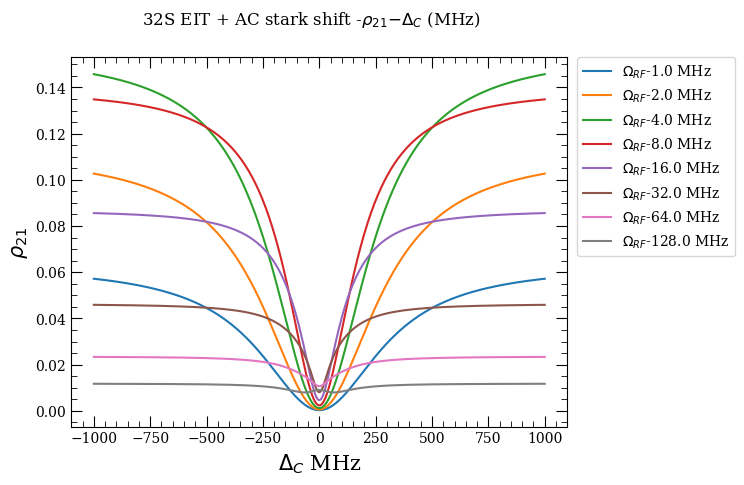

In [15]:
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
for i in range(len(chi_omegaRF_list)):  
 
    plt.plot(deltalist,np.imag(chi_omegaRF_list[i]),label="$\Omega_{RF}$-"+str(omega_RF_list[i]/1E6)+" MHz") 
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xlabel("$\Delta_C$"+" MHz", fontdict = font2)     
    plt.ylabel(r"$\rho_{21}$", fontdict = font2)
plt.suptitle('32S EIT + AC stark shift -' + r"$\rho_{21}$" + "$ - \Delta_C$ (MHz)", fontdict = font2) 
#    plt.yticks([])  
#plt.xlim(-5,5)  
#plt.xlim(-10,10)
# check imaginary path of chi 
plt.show()

In [16]:
deltaP =0   
deltaC =0    
omega =0 
omegaP = 0.1 # Rabi freq. for probe
omegaC = 20 # Rabi freq. for control  
deltalist = np.linspace(-100,100,11)  
rho_12_dopler_avg = [] # list for collecting density 12  
rho_delta = []
rho_vary= []
for deltaC in tqdm(deltalist): 
    rho_12_v =[] 
    for v in v_list: 
        deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
        deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]
        H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP_prime*10**6,omegaC*10**6,0]
            ,[0,omegaC*10**6,-2*(deltaP_prime+deltaC_prime)*10**6,omega],
                    [0,0,omega,0]])
        rho_ss = steadystate(H,collapse) 
        rho_v =-np.imag(expect(sig_12,rho_ss))     
        rho_12_v.append(rho_v)   
    rho_vary.append(rho_12_v)
    rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
    rho_12_dopler_avg = integrate.simpson(rho_list,v_list)/(np.sqrt(np.pi)*u)
    rho_delta.append(rho_12_dopler_avg) 

100%|██████████| 11/11 [00:09<00:00,  1.15it/s]


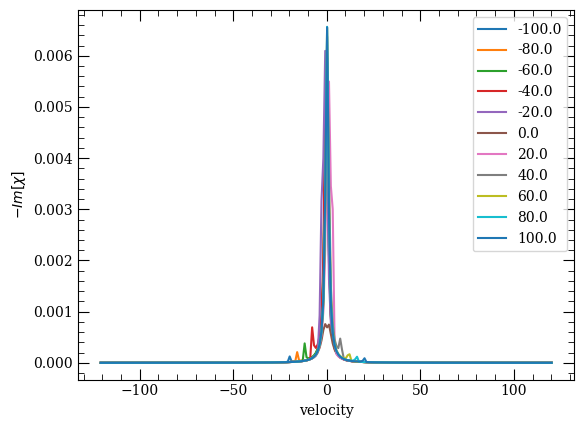

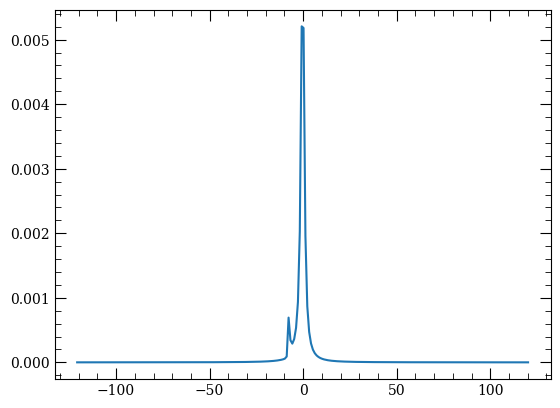

In [17]:
for i in range(len(rho_vary)): 
    plt.plot(v_list,rho_vary[i],label=str(round(deltalist[i],2)))   
plt.xlabel("velocity")     
plt.ylabel(r"$-Im [\chi]$")
plt.legend()
plt.show() 
plt.plot(v_list,rho_vary[3]) 

In [18]:
deltaP =0   
deltaC =0    
omega =0 
omegaP = 0.1 # Rabi freq. for probe
omegaC = 20 # Rabi freq. for control  
deltalist = np.linspace(-100,100,201)  
rho_12_dopler_avg = [] # list for collecting density 12  
rho_delta = []
rho_v_deltaC = []
for deltaC in tqdm(deltalist): 
    rho_12_v =[] 
    for v in v_list: 
        deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
        deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]
        H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP_prime*10**6,omegaC*10**6,0]
            ,[0,omegaC*10**6,-2*(deltaP_prime+deltaC_prime)*10**6,omega],
                    [0,0,omega,0]])
        rho_ss = steadystate(H,collapse) 
        rho_v =-np.imag(expect(sig_12,rho_ss))     
        rho_12_v.append(rho_v)   
    rho_v_deltaC.append(rho_12_v)
    rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
    rho_12_dopler_avg = integrate.simpson(rho_list,v_list)/(np.sqrt(np.pi)*u)
    rho_delta.append(rho_12_dopler_avg) 

100%|██████████| 201/201 [02:47<00:00,  1.20it/s]


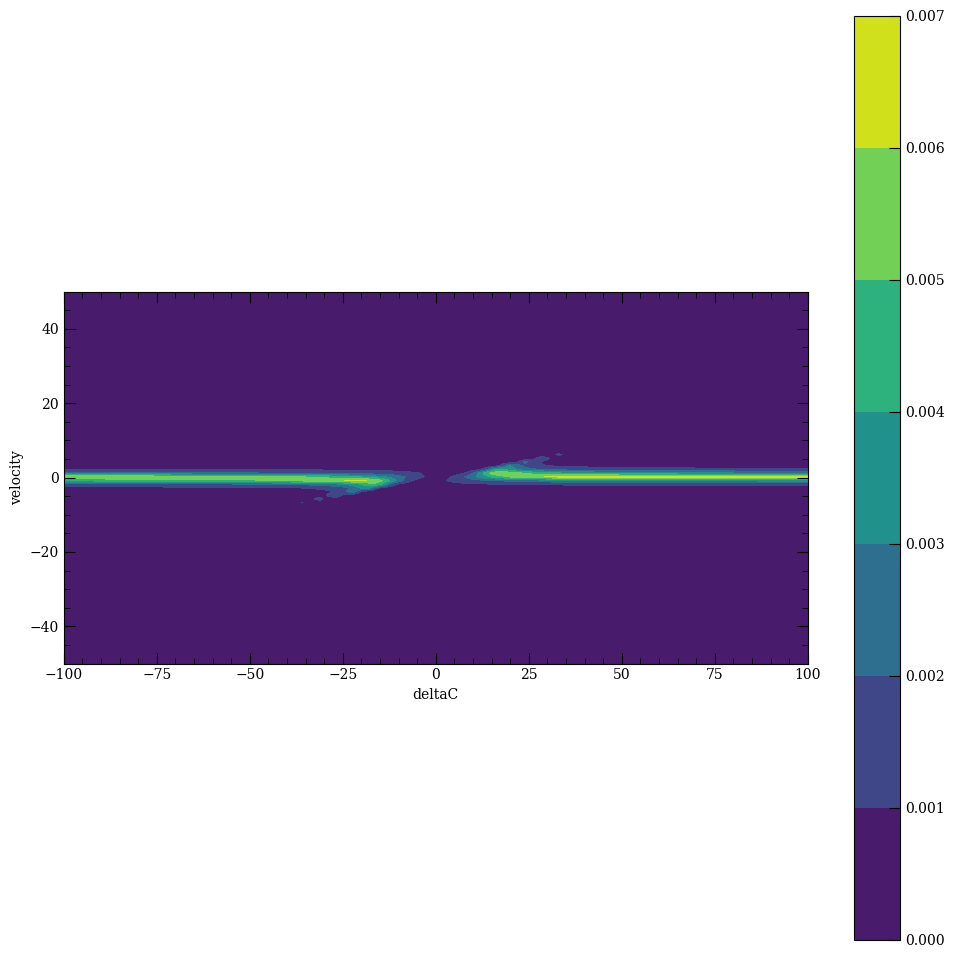

In [19]:
rho_v_deltaC_transpose = np.array(rho_v_deltaC).transpose()
X, Y = np.meshgrid(deltalist, v_list)
fig, ax = plt.subplots(figsize=(12,12))

ax.set_aspect('equal')
contour = ax.contourf(X,Y,rho_v_deltaC_transpose)
fig.colorbar(contour , ax=ax)

plt.xlabel("deltaC")     
plt.ylabel("velocity") 
plt.ylim(-50,50)
plt.show()

In [16]:
deltaP =0   
deltaC =0    
omega =0 
omegaP = 0.1 # Rabi freq. for probe
omegaC = 20 # Rabi freq. for control  
deltalist = np.linspace(-200,200,400)
rho_12_dopler_avg = [] # list for collecting density 12  
rho_delta = []
for deltaC in tqdm(deltalist): 
    rho_12_v =[] 
    for v in v_list: 
        deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
        deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]
        H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP_prime*10**6,omegaC*10**6,0]
               ,[0,omegaC*10**6,-2*(deltaP_prime+deltaC_prime)*10**6,omega],
                       [0,0,omega,0]])
        rho_ss = steadystate(H,collapse) 
        rho_v =-np.imag(expect(sig_12,rho_ss))     
        rho_12_v.append(rho_v)  
    rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
    rho_12_dopler_avg = integrate.simpson(rho_list,v_list)/(np.sqrt(np.pi)*u)
    rho_delta.append(rho_12_dopler_avg) 

100%|██████████| 400/400 [07:08<00:00,  1.07s/it]


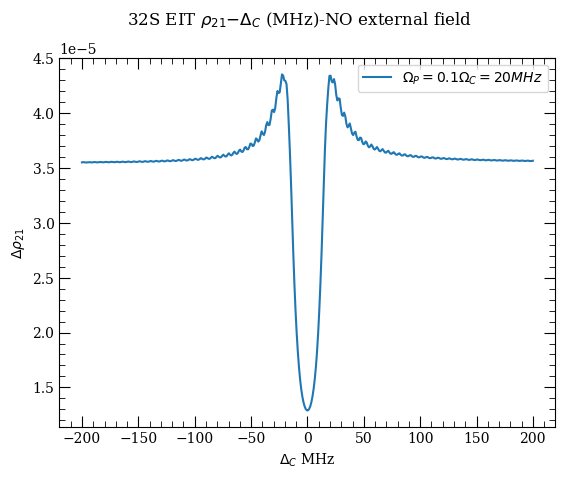

In [17]:
plt.plot(deltalist,rho_delta,label="$\Omega_{P}="+str(omegaP)+"  \Omega_{C}="+str(omegaC)+" MHz$")   
plt.suptitle('32S EIT ' + r"$\rho_{21}$" + "$ - \Delta_C$ (MHz)"+"-NO external field")
plt.xlabel("$\Delta_C$"+" MHz")     
plt.ylabel(r"$\Delta \rho_{21}$")
plt.legend()

In [25]:
n_step = [5*i*i for i in range(7,14)];n_step

[245, 320, 405, 500, 605, 720, 845]

In [26]:
#test for vary n step of delta
deltaP =0   
deltaC =0    
omega =0 
omegaP = 0.1 # Rabi freq. for probe
omegaC = 20 # Rabi freq. for control  
#deltalist = np.linspace(-200,200,400) 
n_step = [5*i*i for i in range(7,14)]
rho_12_dopler_avg = [] # list for collecting density 12   
chi_n = []
for n in tqdm(n_step): 
    rho_delta = []     
    deltalist = np.linspace(-100,100,n)
    for deltaC in deltalist: 
        rho_12_v =[] 
        for v in v_list: 
            deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
            deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]
            H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP_prime*10**6,omegaC*10**6,0]
               ,[0,omegaC*10**6,-2*(deltaP_prime+deltaC_prime)*10**6,omega],
                       [0,0,omega,0]])
            rho_ss = steadystate(H,collapse) 
            rho_v =-np.imag(expect(sig_12,rho_ss))     
            rho_12_v.append(rho_v)  
        rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
        rho_12_dopler_avg = integrate.simpson(rho_list,v_list)/(np.sqrt(np.pi)*u)
        rho_delta.append(rho_12_dopler_avg)   
    chi_n.append(rho_delta)

100%|██████████| 7/7 [49:25<00:00, 423.61s/it]


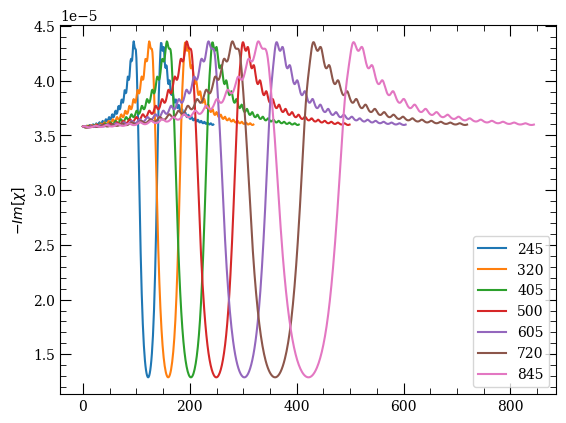

In [32]:
for i in range(len(chi_n)):  
    deltalist = np.linspace(-100,100,n_step[i])
    plt.plot(chi_n[i],label=str(n_step[i]))   
#plt.xlabel("velocity")     
plt.ylabel(r"$-Im [\chi]$")
plt.legend()
plt.show() 


In [33]:
u = sqrt(2*Boltzmann*temperature/mass)
u = round(u, 0);u

242.0

In [34]:
#test for vary n step of velocity 
deltaP =0   
deltaC =0    
omega =0 
omegaP = 0.1 # Rabi freq. for probe
omegaC = 20 # Rabi freq. for control  
deltalist = np.linspace(-100,100,200)  
n_step = [5*i*i for i in range(7,14)]
rho_12_dopler_avg = [] # list for collecting density 12   
chi_n = []
for n in tqdm(n_step): 
    rho_delta = []     
    v_list = np.linspace(-u/2,u/2,n)
    for deltaC in deltalist: 
        rho_12_v =[] 
        for v in v_list: 
            deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
            deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]
            H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP_prime*10**6,omegaC*10**6,0]
               ,[0,omegaC*10**6,-2*(deltaP_prime+deltaC_prime)*10**6,omega],
                       [0,0,omega,0]])
            rho_ss = steadystate(H,collapse) 
            rho_v =-np.imag(expect(sig_12,rho_ss))     
            rho_12_v.append(rho_v)  
        rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
        rho_12_dopler_avg = integrate.simpson(rho_list,v_list)/(np.sqrt(np.pi)*u)
        rho_delta.append(rho_12_dopler_avg)   
    chi_n.append(rho_delta)

100%|██████████| 7/7 [39:55<00:00, 342.15s/it]


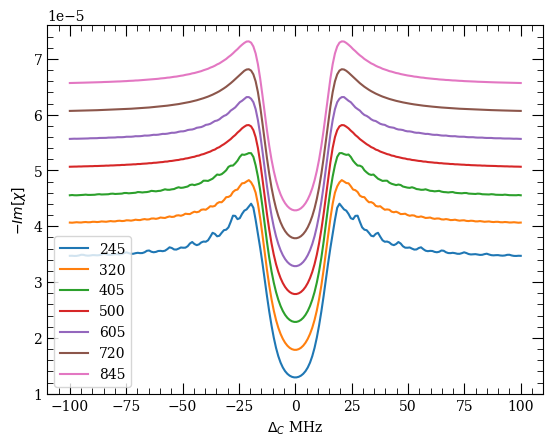

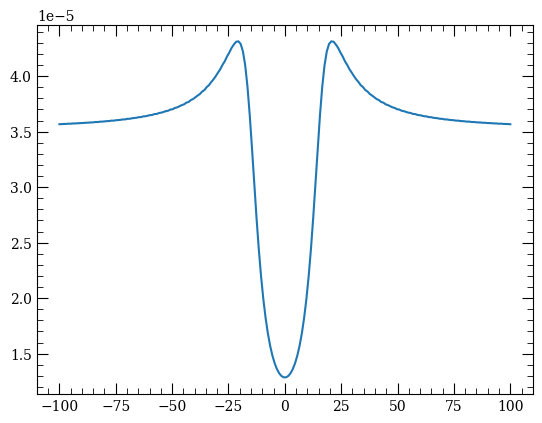

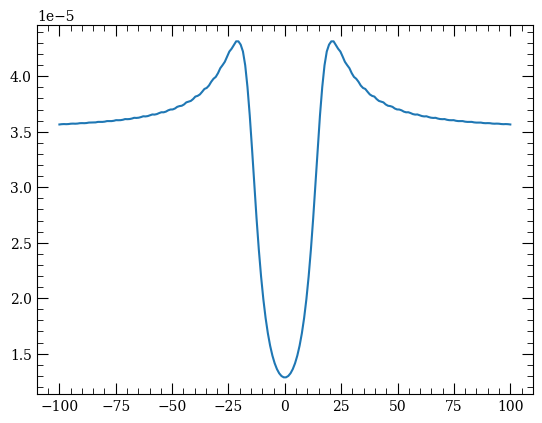

In [46]:

for i in range(len(chi_n)):  
    plt.plot(deltalist,np.array(chi_n[i])+i*0.5e-5,label=str(n_step[i]))   
plt.xlabel("$\Delta_C$"+" MHz")     
plt.ylabel(r"$-Im [\chi]$")
plt.legend()
plt.show()  
plt.plot(deltalist,chi_n[3])  
plt.show()  
plt.plot(deltalist,chi_n[4])  

In [70]:
omegaP_list = [ round(0.1*i,2) for i in range(1,6)];omegaP_list

[0.1, 0.2, 0.3, 0.4, 0.5]

In [73]:
#test for vary probe power 
deltaP =0   
deltaC =0    
omega =0 
#omegaP = 0.1 # Rabi freq. for probe
omegaC = 20 # Rabi freq. for control  
deltalist = np.linspace(-50,50,100) 
v_list = np.linspace(-u/2,u/2,310)
omegaP_list = [ round(0.1*i,2) for i in range(1,6)]
rho_12_dopler_avg = [] # list for collecting density 12   
chi_omega = []
for omegaP in tqdm(omegaP_list): 
    rho_delta = []      
    for deltaC in deltalist: 
        rho_12_v =[] 
        for v in v_list: 
            deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
            deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]
            H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP_prime*10**6,omegaC*10**6,0]
               ,[0,omegaC*10**6,-2*(deltaP_prime+deltaC_prime)*10**6,omega],
                       [0,0,omega,0]])
            rho_ss = steadystate(H,collapse) 
            rho_v =-np.imag(expect(sig_12,rho_ss))     
            rho_12_v.append(rho_v)  
        rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
        rho_12_dopler_avg = integrate.simpson(rho_list,v_list)/(np.sqrt(np.pi)*u)
        rho_delta.append(rho_12_dopler_avg)   
    chi_omega.append(rho_delta)

100%|██████████| 5/5 [08:33<00:00, 102.69s/it]


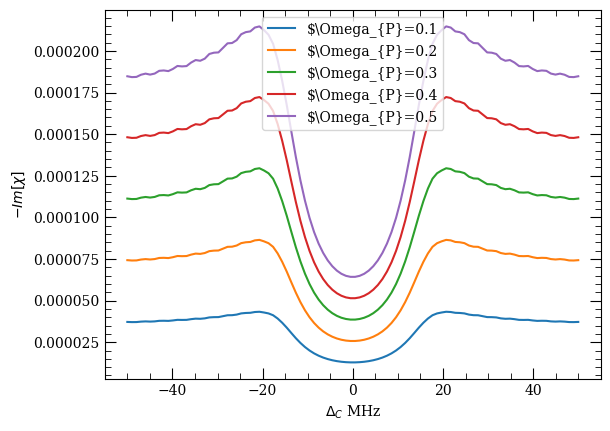

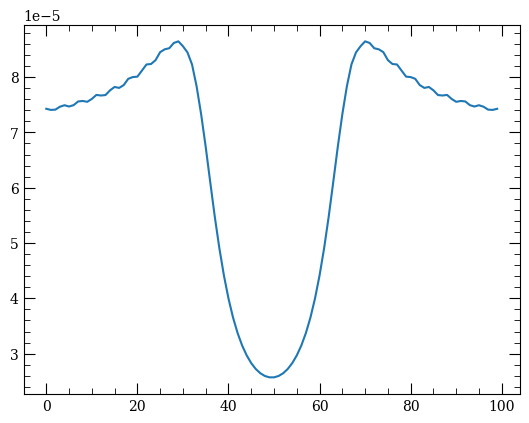

In [75]:
for i in range(len(omegaP_list)):  
    plt.plot(deltalist,np.array(chi_omega[i]),label="$\Omega_{P}="+str(omegaP_list[i]))   
plt.xlabel("$\Delta_C$"+" MHz")     
plt.ylabel(r"$-Im [\chi]$")
plt.legend()
plt.show()  
plt.plot(np.array(chi_omega[1]),label="$\Omega_{P}="+str(omegaP_list[i])) 

In [76]:
debug = 1

# Calculate pressure
def pressure_Rb85(temperature):
    # Pressure of Rb85 in a vapor cell
    # Input temperature in Kelvin
    meltingpoint = 39.30 + 273.15
    if temperature <= meltingpoint:
        pressure = 10**(2.881+4.857-4215/temperature)
    else:
        pressure = 10**(2.881+4.312-4040/temperature)
    pressure = pressure*133.322 #Change from torr to Pascal
    return pressure
if debug: 
    print('Pressure from Steck @ 300K (Pa): ', pressure_Rb85(300))
    print('Pressure from Steck @ 350K (Pa): ', pressure_Rb85(350))
    print('Pressure from Holloway @ 300K (Pa): ',10**(5.006+4.857-4215/300))

# Calculate total density of atoms
def atomdensity(pressure, temperature):
    # Input temperature in Kelvin, pressure in Pa
    kB = 1.380649e-23 # J/K
    return 0.7217*pressure/kB/temperature
if debug: print('Atom density @ 300K, same pressure (atoms/m3)', atomdensity(6.49982733575635e-05, 300))
if debug: print('Atom density @ 350K, same pressure (atoms/m3)', atomdensity(pressure_Rb85(350), 350))

# Calculate electric field from Rabi frequency
def E_from_Rabi(rabifreq,dipmat):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    hbar = 1.054571817e-34 # J.s
    return rabifreq*hbar/(dipmat*ea0)
if debug: print('E from Rabifreq (V/m): ', E_from_Rabi(1e6,2.44063075))

# Calculate susceptibility \chi
def susceptibility(atomdensity,dipmat,Efield,rho12):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    if Efield == 0: res = 1e99 #give large value
    else: res = 2*atomdensity*(dipmat*ea0)*rho12/Efield/epsilon0
    return res
if debug: print('chi from E :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(1e6,2.44063075),0.12309365719942876))
if debug: print('chi when E=0 :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(0,2.44063075),0.12309365719942876))

# Transmission P/P0
def transmission(L,chi_imag,lambda12):
    # from Beer's law, alpha should be  around 10 m-1, transmission is around 0.8
    # chi should be in the order of 1e-5 to 1e-8
    return np.exp(-2*pi*L*chi_imag/lambda12)
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e-5,780e-9))
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e99,780e-9))

def absorption_coeff_0(atomdensity,dipmat,lambda12,gamma2):
    # From Berman's book, eq. 4.23
    # gamma2 is spontaneous emission
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    hbar = 1.054571817e-34 # J.s
    speed_of_light = 299792458 # m/s
    a0 =  2*atomdensity*(dipmat*ea0)**2/hbar/epsilon0/gamma2
    # return a0* gamma2/2 *freq/(speed_of_light/lambda12) * gamma/(gammaB**2+delta**2)
    return a0

if debug: print('absorption coefficient',absorption_coeff_0(1e16,2.44063075,780e-9,6e6))

print(np.exp(-7.5e-2*absorption_coeff_0(1e16,2.44063075,780e-9,6e6)))

Pressure from Steck @ 300K (Pa):  6.49982733575635e-05
Pressure from Steck @ 350K (Pa):  0.0059572342419839325
Pressure from Holloway @ 300K (Pa):  6.50129690343089e-05
Atom density @ 300K, same pressure (atoms/m3) 1.1325411426595652e+16
Atom density @ 350K, same pressure (atoms/m3) 8.897132440591974e+17
E from Rabifreq (V/m):  5.096388832415705
chi from E : 0.001278562547981584
chi when E=0 : 1e+99
Transmission (P/P0): 0.0023779313882871726
Transmission (P/P0): 0.0
absorption coefficient 0.001528554983971162
0.999885364947302


In [90]:
lambda12

7.802415056628226e-07

In [77]:
area = np.pi*(1.27e-2)**2
length = 7.8e-2
volume = area*length 
L=7.5e-2 # Cell length

pressure = pressure_Rb85(temperature)
N_0 = atomdensity(pressure, temperature)

print('volume (m3):', volume)
# print('Atom ')

volume (m3): 3.952318336960482e-05


[3.857256836559428e-06, 3.84673774179191e-06, 3.849363783059486e-06, 3.8767862617431426e-06, 3.890670752372796e-06, 3.878634664277039e-06, 3.891463054537859e-06, 3.926161577277302e-06, 3.930721917558957e-06, 3.9227910685047835e-06, 3.949800880360942e-06, 3.987462294046672e-06, 3.982004104205632e-06, 3.98626516187303e-06, 4.030559950680407e-06, 4.062199250568672e-06, 4.0532684838215524e-06, 4.079834105670581e-06, 4.138916974209436e-06, 4.155104465835327e-06, 4.1589896197026156e-06, 4.216017069813081e-06, 4.2734375417590865e-06, 4.277703786605982e-06, 4.314308038328912e-06, 4.389004695189399e-06, 4.4157722423112796e-06, 4.4258480930081196e-06, 4.475199544258203e-06, 4.490568265832203e-06, 4.444832831188959e-06, 4.3868094126420365e-06, 4.273507480340356e-06, 4.069097988423294e-06, 3.8059618571376476e-06, 3.500136221400116e-06, 3.167722141809908e-06, 2.8425453870142326e-06, 2.548275768281567e-06, 2.292687182964597e-06, 2.076568972326185e-06, 1.8977665171181368e-06, 1.752204057216156e-06, 1

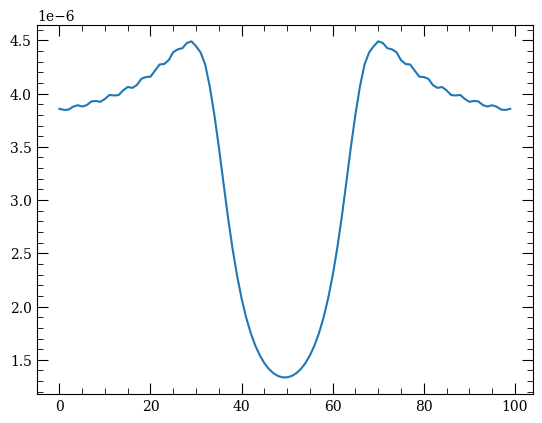

Text(0, 0.5, 'Transmission (P/P$_{0}$)')

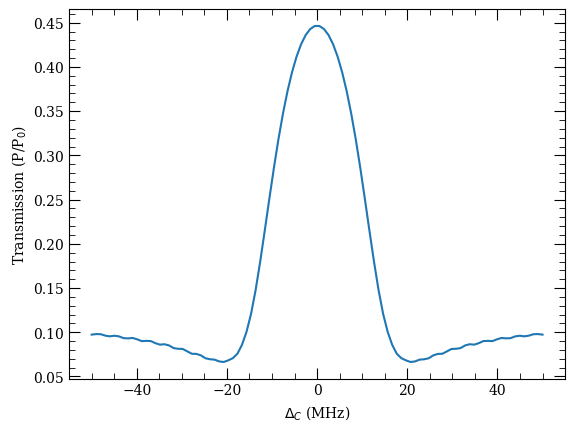

In [95]:
Efield = E_from_Rabi(omegaP_list[1]*1e6,abs(dipmat12))
# print()
chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in chi_omega[1]]
print(chi) 
plt.plot(chi)
transmittance = [transmission(L,i,lambda12) for i in chi]
plt.show()
plt.plot(deltalist,transmittance, label=str(round(rabi12*1e-6,0))+'MHz') 
plt.xlabel('$\Delta_{C}$ (MHz)') 
plt.ylabel('Transmission (P/P$_{0}$)') 

In [101]:
omega_list = [ round(8*i,2) for i in range(1,6)];omega_list

[8, 16, 24, 32, 40]

In [111]:
deltaP =0   
deltaC =0      
deltaRF = 0
omega =10*10**6
omegaP = 0.6 # Rabi freq. for probe
omegaC = 20 # Rabi freq. for control  
deltalist = np.linspace(-100,100,11)  
rho_12_dopler_avg = [] # list for collecting density 12  
rho_delta = []
rho_vary= [] 
for deltaC in tqdm(deltalist): 
    rho_12_v =[] 
    for v in v_list: 
        deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
        deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]  
        deltaRF_prime = deltaRF - 2*pi*v*1E-6/lambda_trans[2] 
        H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP_prime*10**6,omegaC*10**6,0]
            ,[0,omegaC*10**6,-2*(deltaP_prime+deltaC_prime)*10**6,omega],
                    [0,0,omega,-2*(deltaP_prime+deltaC_prime+deltaRF_prime)*10**6]])
        rho_ss = steadystate(H,collapse) 
        rho_v =-np.imag(expect(sig_12,rho_ss))     
        rho_12_v.append(rho_v)   
    rho_vary.append(rho_12_v)
    rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
    rho_12_dopler_avg = integrate.simpson(rho_list,v_list)/(np.sqrt(np.pi)*u)
    rho_delta.append(rho_12_dopler_avg) 

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:22<00:00,  2.08s/it]


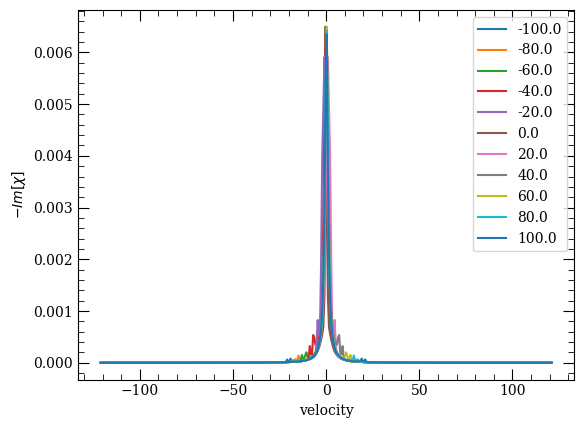

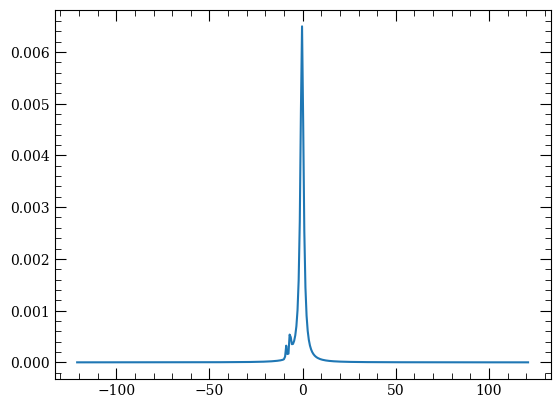

In [113]:
for i in range(len(rho_vary)): 
    plt.plot(v_list,rho_vary[i],label=str(round(deltalist[i],2)))   
plt.xlabel("velocity")     
plt.ylabel(r"$-Im [\chi]$")
plt.legend()
plt.show() 
plt.plot(v_list,rho_vary[3]) 

In [117]:
deltaP =0   
deltaC =0      
deltaRF = 0
omega =20*10**6
omegaP = 0.6 # Rabi freq. for probe
omegaC = 20 # Rabi freq. for control  
deltalist = np.linspace(-50,50,201)  
rho_12_dopler_avg = [] # list for collecting density 12  
rho_delta = []
rho_vary= [] 
for deltaC in tqdm(deltalist): 
    rho_12_v =[] 
    for v in v_list: 
        deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
        deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]  
        deltaRF_prime = deltaRF - 2*pi*v*1E-6/lambda_trans[2] 
        H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP_prime*10**6,omegaC*10**6,0]
            ,[0,omegaC*10**6,-2*(deltaP_prime+deltaC_prime)*10**6,omega],
                    [0,0,omega,-2*(deltaP_prime+deltaC_prime+deltaRF_prime)*10**6]])
        rho_ss = steadystate(H,collapse) 
        rho_v =-np.imag(expect(sig_12,rho_ss))     
        rho_12_v.append(rho_v)  
    rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
    rho_12_dopler_avg = integrate.simpson(rho_list,v_list)/(np.sqrt(np.pi)*u)
    rho_delta.append(rho_12_dopler_avg) 

  0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 201/201 [06:09<00:00,  1.84s/it]


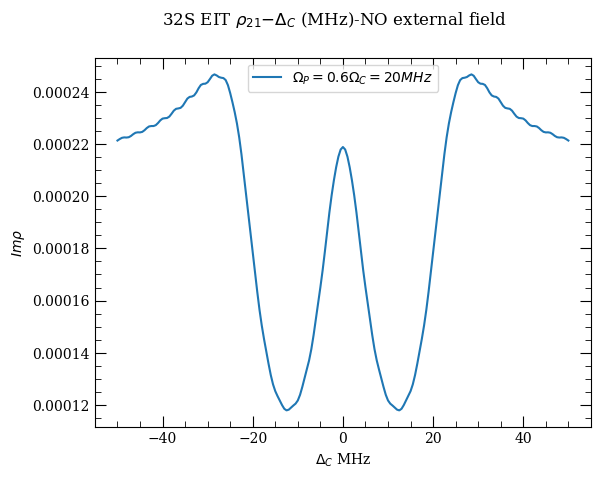

In [118]:
plt.plot(deltalist,rho_delta,label="$\Omega_{P}="+str(omegaP)+"  \Omega_{C}="+str(omegaC)+" MHz$")   
plt.suptitle('32S EIT ' + r"$\rho_{21}$" + "$ - \Delta_C$ (MHz)"+"-NO external field")
plt.xlabel("$\Delta_C$"+" MHz")     
plt.ylabel(r"$Im \rho$")
plt.legend()

[3.833092533434816e-06, 3.843023462368491e-06, 3.851209133095962e-06, 3.853918586404023e-06, 3.853074200288649e-06, 3.855152735892635e-06, 3.863554838367002e-06, 3.875531566165129e-06, 3.88490524061052e-06, 3.887704466712861e-06, 3.887103624529502e-06, 3.890654954570195e-06, 3.901591991104743e-06, 3.916097567015299e-06, 3.926690944590426e-06, 3.92948499375985e-06, 3.9294876122647645e-06, 3.935336836124979e-06, 3.9497124579951284e-06, 3.9672185620076065e-06, 3.978871193706172e-06, 3.981571248715135e-06, 3.982858950004848e-06, 3.992212086578402e-06, 4.01107927944602e-06, 4.031782692417946e-06, 4.043933807230025e-06, 4.046531730070947e-06, 4.050236172137186e-06, 4.064582124157758e-06, 4.088659598003219e-06, 4.111752804522365e-06, 4.123041153643194e-06, 4.125577205567793e-06, 4.132949043141317e-06, 4.152993899544102e-06, 4.180822521076283e-06, 4.202617265979301e-06, 4.209771983485866e-06, 4.210996644006128e-06, 4.220512191496729e-06, 4.2414338255442195e-06, 4.26367773424025e-06, 4.27273910

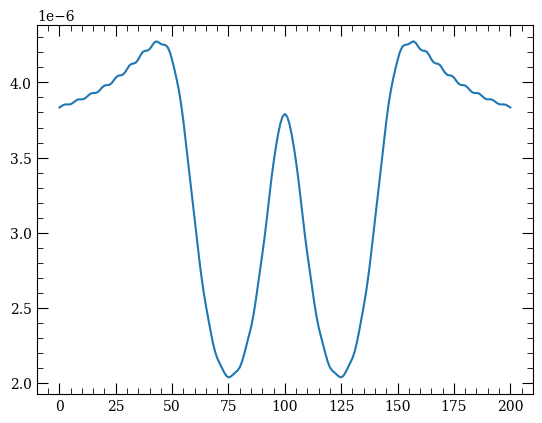

Text(0, 0.5, 'Transmission (P/P$_{0}$)')

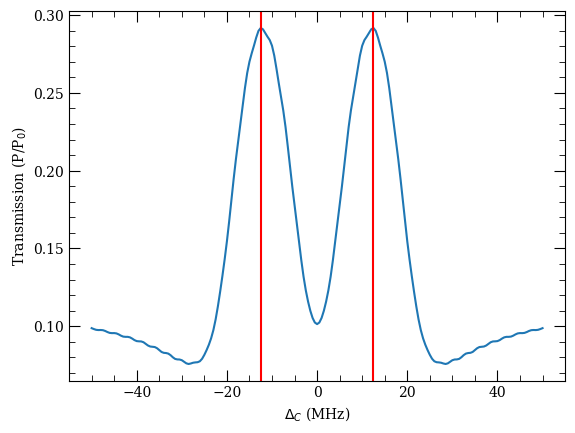

In [125]:
Efield = E_from_Rabi(0.6*1e6,abs(dipmat12))
# print()
chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in rho_delta]
print(chi) 
plt.plot(chi)
transmittance = [transmission(L,i,lambda12) for i in chi]
plt.show()
plt.plot(deltalist,transmittance, label=str(round(rabi12*1e-6,0))+'MHz')  
plt.axvline(x = -12.5, color = 'r', label = 'axvline - full height') 
plt.axvline(x = 12.5, color = 'r', label = 'axvline - full height')
plt.xlabel('$\Delta_{C}$ (MHz)') 
plt.ylabel('Transmission (P/P$_{0}$)') 

In [126]:
deltaP =0   
deltaC =0      
deltaRF = 0
#omega =20*10**6
omegaP = 0.6 # Rabi freq. for probe
omegaC = 20 # Rabi freq. for control  
deltalist = np.linspace(-100,100,251)   
omega_list = [15*i for i in range(5)]
rho_12_dopler_avg = [] # list for collecting density 12  
rho_vary= []  
for omega in tqdm(omega_list): 
    rho_delta = []
    for deltaC in deltalist: 
        rho_12_v =[] 
        for v in v_list: 
            deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
            deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]  
            deltaRF_prime = deltaRF - 2*pi*v*1E-6/lambda_trans[2] 
            H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP_prime*10**6,omegaC*10**6,0]
                ,[0,omegaC*10**6,-2*(deltaP_prime+deltaC_prime)*10**6,omega*10**6],
                    [0,0,omega*10**6,-2*(deltaP_prime+deltaC_prime+deltaRF_prime)*10**6]])
            rho_ss = steadystate(H,collapse) 
            rho_v =-np.imag(expect(sig_12,rho_ss))     
            rho_12_v.append(rho_v)  
        rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
        rho_12_dopler_avg = integrate.simpson(rho_list,v_list)/(np.sqrt(np.pi)*u)
        rho_delta.append(rho_12_dopler_avg)  
    rho_vary.append(rho_delta)

100%|██████████| 5/5 [35:37<00:00, 427.52s/it]


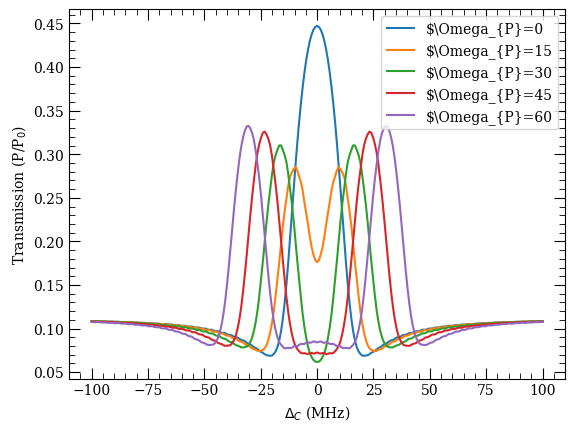

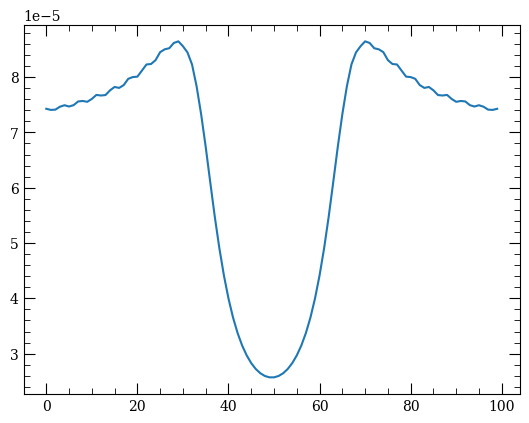

In [130]:
for i in range(len(rho_vary)):   
    Efield = E_from_Rabi(0.6*1e6,abs(dipmat12))
# print()
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in rho_vary[i]] 
    transmittance = [transmission(L,i,lambda12) for i in chi]
    plt.plot(deltalist,transmittance ,label="$\Omega_{P}="+str(omega_list[i]))     
plt.xlabel('$\Delta_{C}$ (MHz)') 
plt.ylabel('Transmission (P/P$_{0}$)')
plt.legend()
plt.show()  
plt.plot(np.array(chi_omega[1]),label="$\Omega_{P}="+str(omegaP_list[i]))

In [ ]:
for i in range(len(rho_vary)):  
    plt.plot(deltalist,np.array(rho_vary[i]),label="$\Omega_{P}="+str(omega_list[i]))   
plt.xlabel("$\Delta_C$"+" MHz")     
plt.ylabel(r"$-Im [\chi]$")
plt.legend()
plt.show()  
plt.plot(np.array(chi_omega[1]),label="$\Omega_{P}="+str(omegaP_list[i]))

In [243]:
u = sqrt(2*Boltzmann*temperature/mass);u
v_list = np.arange(-3*u,3*u,8)

In [354]:
def EIT_peak_dopler(omegaP,omegaC): 
    deltaP =0   
    omega =0  
    deltalist = np.linspace(-50,50,65) 
    rho_12_dopler_avg = [] # list for collecting density 12  
    rho_delta = [] 
    for deltaC in deltalist: 
        rho_12_v =[] 
        for v in v_list: 
            deltaP_prime = deltaP + 2*pi*v*1E-6/lambda_trans[0]
            deltaC_prime = deltaC - 2*pi*v*1E-6/lambda_trans[1]
            H = 1/2*Qobj([[0,omegaP*10**6,0,0],[omegaP*10**6,-2*deltaP*10**6,omegaC*10**6,0]
               ,[0,omegaC*10**6,-2*(deltaP+deltaC)*10**6,omega],
                       [0,0,omega,0]])
            rho_ss = steadystate(H,collapse) 
            rho_v =np.imag(expect(sig_12,rho_ss))     
            rho_12_v.append(rho_v*np.exp(-(v/u)**2))  
 #       rho_list = np.multiply(rho_12_v,np.exp(-(v/u)**2)) 
        rho_12_dopler_avg = integrate.simpson(rho_12_v,v_list)
        rho_delta.append(rho_12_dopler_avg)  
        rho_delta/(np.sqrt(np.pi)*u) 
        

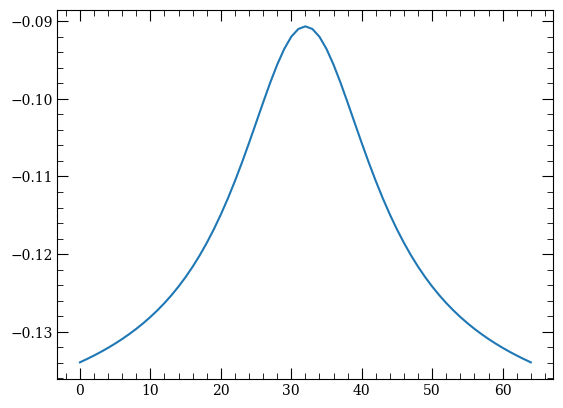

In [355]:
plt.plot(EIT_peak_dopler(20,40))

In [261]:
omegaC = np.linspace(40.0, 0, 21)
omegaP = np.linspace(0,40.0, 21) 
print(omegaP,omegaC)

[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 22. 24. 26. 28. 30. 32. 34.
 36. 38. 40.] [40. 38. 36. 34. 32. 30. 28. 26. 24. 22. 20. 18. 16. 14. 12. 10.  8.  6.
  4.  2.  0.]


In [266]:
for j in omegaC: 
    for i in tqdm(omegaP): 
        df = pd.DataFrame(EIT_peak_dopler(i,j),columns = ['rho_12'])  
        df.to_csv("E:\EIT\EIT_qutip\EIT_no_ex_field_32s_doppler\omegaP"+str(i)+"_omegaC"+str(j)+".csv", index=False)

100%|██████████| 21/21 [13:35<00:00, 38.84s/it]


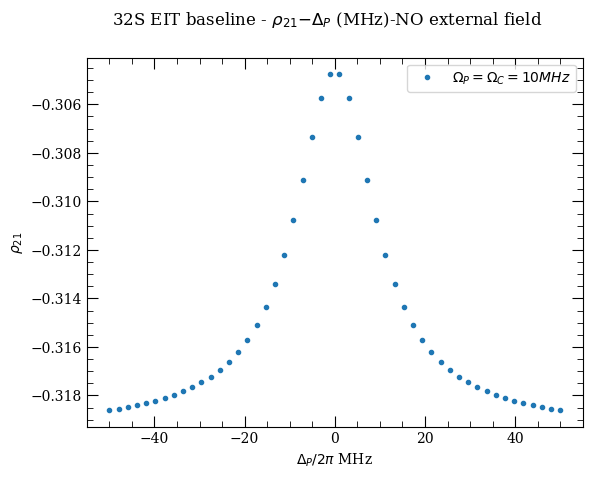

In [242]:
plt.plot(deltalist,rho_delta,'.',label="$\Omega_{P}=\Omega_{C}=10 MHz$")   
plt.suptitle('32S EIT baseline - ' + r"$\rho_{21}$" + "$ - \Delta_P$ (MHz)"+"-NO external field")
plt.xlabel("$\Delta_P / 2\pi$"+" MHz")     
plt.ylabel(r"$\rho_{21}$")  
plt.legend()

In [267]:
path='E:\EIT\EIT_qutip\EIT_no_ex_field_32s_doppler\omegaP4.0_omegaC16.0.csv'  
df = pd.read_csv(path)
yval = df['rho_12'].values

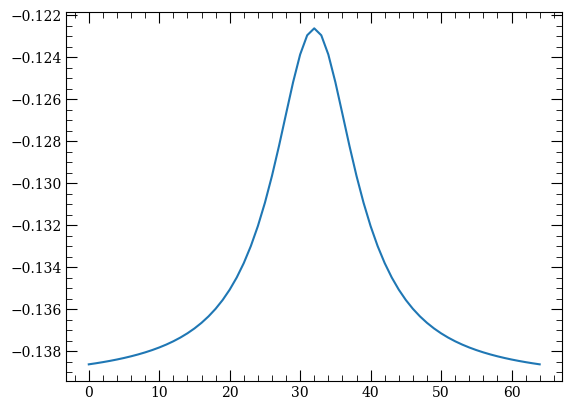

In [268]:
plt.plot(yval)

In [269]:
def peak_cut(omegaP,omegaC):  
    path='E:\EIT\EIT_qutip\EIT_no_ex_field_32s_doppler\omegaP'+str(omegaP)+'_omegaC'+str(omegaC)+'.csv'  
    df = pd.read_csv(path) 
    yval = df['rho_12'].values 
    return yval

In [272]:
omegaC = np.linspace(40.0, 0, 21)
omegaP = np.linspace(0,40.0, 21) 
O_p, O_c = np.meshgrid(omegaP, omegaC)

In [273]:
peak_hieght_fit = [[np.max(peak_cut(i,j))-np.min(peak_cut(i,j)) for i in omegaP] for j in tqdm(omegaC) ] 

100%|██████████| 21/21 [00:03<00:00,  5.86it/s]


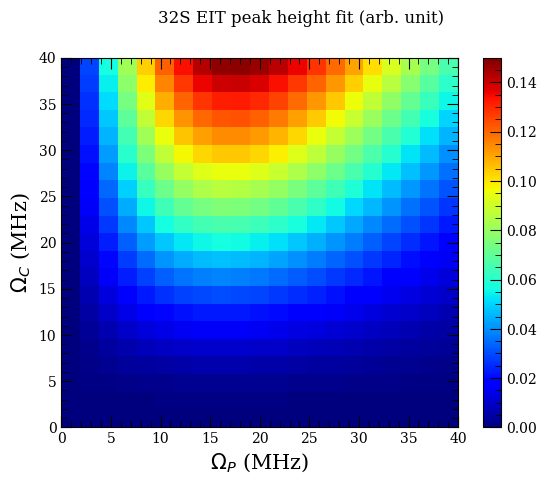

In [277]:
plt.imshow(peak_hieght_fit,vmin=0.00,origin='upper', extent=[0,40,0,40], vmax=0.15, cmap='jet', aspect='auto')  
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
plt.suptitle('32S EIT peak height fit (arb. unit)', fontdict = font1)
plt.xlabel("$\Omega_P$"+" (MHz)", fontdict = font2)
plt.ylabel("$\Omega_C$"+" (MHz)", fontdict = font2)
plt.colorbar()

In [279]:
deltalist = np.linspace(-50,50,65) 

  0%|          | 0/101 [3:03:33<?, ?it/s]


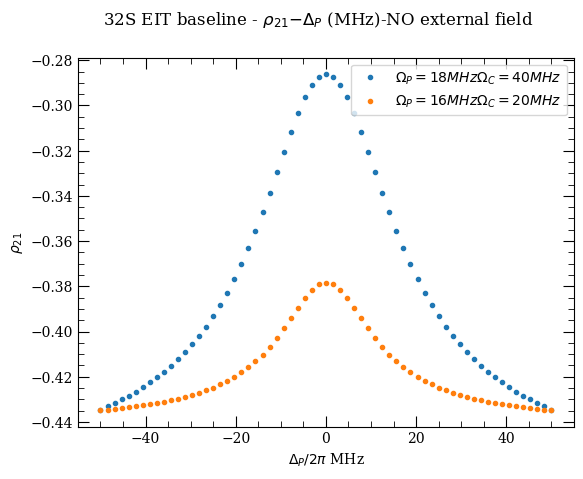

In [285]:
plt.plot(deltalist,peak_cut(18.0,40.0),'.',label="$\Omega_{P}=18 MHz \Omega_{C}=40 MHz$")    
plt.plot(deltalist,peak_cut(16.0,20.0),'.',label="$\Omega_{P}=16 MHz \Omega_{C}=20 MHz$")
plt.suptitle('32S EIT baseline - ' + r"$\rho_{21}$" + "$ - \Delta_P$ (MHz)"+"-NO external field")
plt.xlabel("$\Delta_P / 2\pi$"+" MHz")     
plt.ylabel(r"$\rho_{21}$")  
plt.legend()

In [307]:
omegaP_list = [0.001*10**(i) for i in range(0,5) ]  
omegaC_power = [2**(i) for i in range(0,8)] ;omegaC_power

[1, 2, 4, 8, 16, 32, 64, 128]

### Power comprehension

In [308]:
for j in omegaC_power: 
    for i in tqdm(omegaP_list): 
        df = pd.DataFrame(EIT_peak_dopler(i,j*i),columns = ['rho_12'])  
        df.to_csv("E:\EIT\EIT_qutip\EIT_no_ex_field_32s_doppler_power\omegaP"+str(i)+"_omegaC"+str(j*i)+".csv", index=False)

100%|██████████| 5/5 [03:35<00:00, 43.10s/it]


In [309]:
def peak_cut_power(omegaP,omegaC):  
    path='E:\EIT\EIT_qutip\EIT_no_ex_field_32s_doppler_power\omegaP'+str(omegaP)+'_omegaC'+str(omegaC)+'.csv'  
    df = pd.read_csv(path) 
    yval = df['rho_12'].values 
    return yval

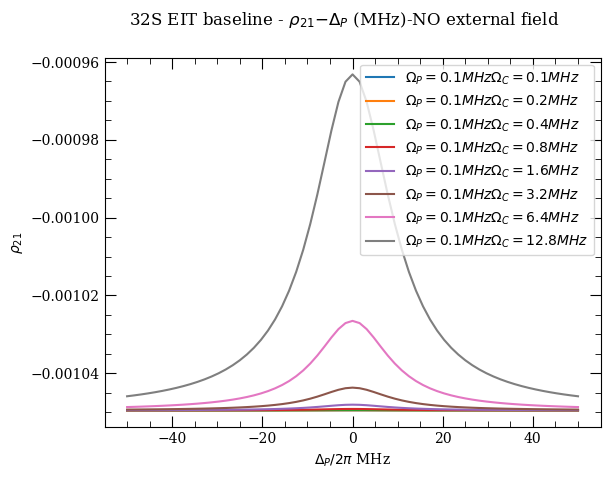

In [317]:
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
for i in omegaC_power:  
 
    plt.plot(deltalist,peak_cut_power(omegaP_list[2],omegaP_list[2]*i),'-',label="$\Omega_{P}="+str(omegaP_list[2])+"MHz \Omega_{C}="+str(omegaP_list[2]*i)+" MHz$")    
plt.suptitle('32S EIT baseline - ' + r"$\rho_{21}$" + "$ - \Delta_P$ (MHz)"+"-NO external field")
plt.xlabel("$\Delta_P / 2\pi$"+" MHz")     
plt.ylabel(r"$\rho_{21}$")  
plt.legend()
 

### best line height

In [322]:
peak_hieght_fit = [[np.max(peak_cut_power(j,i*j))-np.min(peak_cut_power(j,i*j)) for i in tqdm(omegaC_power)] for j in omegaP_list ] 

100%|██████████| 8/8 [00:00<00:00, 351.27it/s]


In [327]:
peak_hieght_fit[1]

[5.527400003088774e-12,
 2.210959999880257e-11,
 8.843829999111239e-11,
 3.537522000047859e-10,
 1.414992999995094e-09,
 5.659717600004356e-09,
 2.263480239999801e-08,
 9.04741772999988e-08]

In [332]:
power = [np.log2(i) for i in omegaC_power] ;power

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]

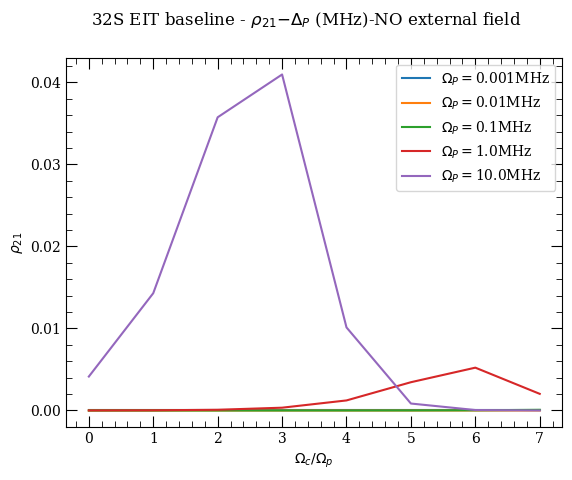

In [338]:
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}  
power = [np.log2(i) for i in omegaC_power]
for i in range(len(omegaP_list)):  
    plt.plot(power,peak_hieght_fit[i],'-',label="$\Omega_{P}=$"+str(omegaP_list[i])+"MHz" )    
plt.suptitle('32S EIT baseline - ' + r"$\rho_{21}$" + "$ - \Delta_P$ (MHz)"+"-NO external field")
plt.xlabel("$\Omega_{c}/\Omega_{p}$")     
plt.ylabel(r"$\rho_{21}$")  
plt.legend()

### Add doppler adjust constant

In [356]:
debug = 1

# Calculate pressure
def pressure_Rb85(temperature):
    # Pressure of Rb85 in a vapor cell
    # Input temperature in Kelvin
    meltingpoint = 39.30 + 273.15
    if temperature <= meltingpoint:
        pressure = 10**(2.881+4.857-4215/temperature)
    else:
        pressure = 10**(2.881+4.312-4040/temperature)
    pressure = pressure*133.322 #Change from torr to Pascal
    return pressure
if debug: 
    print('Pressure from Steck @ 300K (Pa): ', pressure_Rb85(300))
    print('Pressure from Steck @ 350K (Pa): ', pressure_Rb85(350))
    print('Pressure from Holloway @ 300K (Pa): ',10**(5.006+4.857-4215/300))

# Calculate total density of atoms
def atomdensity(pressure, temperature):
    # Input temperature in Kelvin, pressure in Pa
    kB = 1.380649e-23 # J/K
    return 0.7217*pressure/kB/temperature
if debug: print('Atom density @ 300K, same pressure (atoms/m3)', atomdensity(6.49982733575635e-05, 300))
if debug: print('Atom density @ 350K, same pressure (atoms/m3)', atomdensity(pressure_Rb85(350), 350))

# Calculate electric field from Rabi frequency
def E_from_Rabi(rabifreq,dipmat):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    hbar = 1.054571817e-34 # J.s
    return rabifreq*hbar/(dipmat*ea0)
if debug: print('E from Rabifreq (V/m): ', E_from_Rabi(1e6,2.44063075))

# Calculate susceptibility \chi
def susceptibility(atomdensity,dipmat,Efield,rho12):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    if Efield == 0: res = 1e99 #give large value
    else: res = 2*atomdensity*(dipmat*ea0)*rho12/Efield/epsilon0
    return res
if debug: print('chi from E :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(1e6,2.44063075),0.12309365719942876))
if debug: print('chi when E=0 :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(0,2.44063075),0.12309365719942876))

# Transmission P/P0
def transmission(L,chi_imag,lambda12):
    # from Beer's law, alpha should be  around 10 m-1, transmission is around 0.8
    # chi should be in the order of 1e-5 to 1e-8
    return np.exp(-2*pi*L*chi_imag/lambda12)
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e-5,780e-9))
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e99,780e-9))

def absorption_coeff_0(atomdensity,dipmat,lambda12,gamma2):
    # From Berman's book, eq. 4.23
    # gamma2 is spontaneous emission
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    hbar = 1.054571817e-34 # J.s
    speed_of_light = 299792458 # m/s
    a0 =  2*atomdensity*(dipmat*ea0)**2/hbar/epsilon0/gamma2
    # return a0* gamma2/2 *freq/(speed_of_light/lambda12) * gamma/(gammaB**2+delta**2)
    return a0

if debug: print('absorption coefficient',absorption_coeff_0(1e16,2.44063075,780e-9,6e6))

print(np.exp(-7.5e-2*absorption_coeff_0(1e16,2.44063075,780e-9,6e6)))

Pressure from Steck @ 300K (Pa):  6.49982733575635e-05
Pressure from Steck @ 350K (Pa):  0.0059572342419839325
Pressure from Holloway @ 300K (Pa):  6.50129690343089e-05
Atom density @ 300K, same pressure (atoms/m3) 1.1325411426595652e+16
Atom density @ 350K, same pressure (atoms/m3) 8.897132440591974e+17
E from Rabifreq (V/m):  5.096388832415705
chi from E : 0.001278562547981584
chi when E=0 : 1e+99
Transmission (P/P0): 0.0023779313882871726
Transmission (P/P0): 0.0
absorption coefficient 0.001528554983971162
0.999885364947302


In [360]:
L=7.5e-2 # Cell length

pressure = pressure_Rb85(temperature)
N_0 = atomdensity(pressure, temperature)

area = np.pi*(1.27e-2)**2
length = 7.8e-2
volume = area*length

print('volume (m3):', volume)
# print('Atom ')

volume (m3): 3.952318336960482e-05


In [361]:
temperature

300

In [560]:
# create list of delta_p values
deltalist = np.linspace(-500,500,201)
# empty list to save results
chi = [] # susceptibility

In [561]:
#define Rabies frequency 
#E=1E3
deltaC = 0 # coupling field detuning  
deltaC_list = [0.1*i for i in range(0,6)]
deltaRF = 0 
#For omegaP and OmagaC is 1 MHz
omegaP = 1E6 # Rabi freq. for probe
omegaC = 100E6 # Rabi freq. for control  
omegaP_list = [(10*i)*1e6 for i in range(7)]
deltaP0 = 1E6

In [562]:
deltaP =0  
deltaC = 0 
omega = 0 
omegaP = 40E6 # Rabi freq. for probe
omegaC = 100E6 # Rabi freq. for control 
res=[]
for deltaC in deltalist:
    H = 1/2*Qobj([[0,omegaP,0,0],[omegaP,-2*(deltaP)*10**6,omegaC,0]
            ,[0,omegaC,-2*(deltaP+deltaC)*10**6,0],
                       [0,0,0,-2*(deltaP+deltaC+deltaRF)*10**6]])
    rho_ss = steadystate(H,collapse)  
    res.append(expect(sig_12.dag(),rho_ss)) 
Efield = E_from_Rabi(omegaP,abs(dipmat12))   
chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]  
transmittance = [transmission(L,np.imag(i),lambda12) for i in chi] 


In [563]:
transmittance_list=[] 
deltaP =0  
deltaC = 0 
omega = 0
for omegaP in tqdm(omegaP_list) : 
    res=[]
    for deltaC in deltalist:
        H = 1/2*Qobj([[0,omegaP,0,0],[omegaP,-2*(deltaP)*10**6,omegaC,0]
               ,[0,omegaC,-2*(deltaP+deltaC)*10**6,omega],
                       [0,0,omega,-2*(deltaP+deltaC+deltaRF)*10**6]])
        rho_ss = steadystate(H,collapse)  
        res.append(expect(sig_12.dag(),rho_ss)) 
    Efield = E_from_Rabi(omegaP,abs(dipmat12))   
    print(Efield)
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]  
    transmittance = [transmission(L,np.imag(i),lambda12) for i in chi] 
    print(transmittance)
    refraction = np.real(chi)
    absorption = 2*pi*np.imag(chi)/lambda12 
    transmittance_list.append(transmittance)

 14%|█▍        | 1/7 [00:00<00:04,  1.34it/s]

0.0
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 

 29%|██▊       | 2/7 [00:01<00:03,  1.38it/s]

50.96388822225328
[3.998798182656487e-31, 4.567161096115551e-31, 5.234523617445512e-31, 6.021059302276968e-31, 6.95162778805484e-31, 8.056994493840434e-31, 9.375401668718227e-31, 1.095460175411806e-30, 1.2854502165817942e-30, 1.51506229239607e-30, 1.793864074035884e-30, 2.134039332431663e-30, 2.5511857455112323e-30, 3.0653810669265492e-30, 3.702616380339627e-30, 4.496734615421461e-30, 5.492068985942715e-30, 6.747057433950716e-30, 8.339227367120804e-30, 1.0372117819450238e-29, 1.2984960799086895e-29, 1.6366321608875013e-29, 2.0773463588172845e-29, 2.656005610600938e-29, 3.421614296001593e-29, 4.442628079999319e-29, 5.815484239660598e-29, 7.677230109533952e-29, 1.0224391988746931e-28, 1.3741438899084897e-28, 1.8644146424222527e-28, 2.5546338847600496e-28, 3.536370462170063e-28, 4.947705352397712e-28, 6.9991970869950865e-28, 1.0015665045574184e-27, 1.4504246310246417e-27, 2.1266645953189514e-27, 3.1586697332144673e-27, 4.754799889016935e-27, 7.25793743731926e-27, 1.1240515173181524e-26, 1

 43%|████▎     | 3/7 [00:02<00:02,  1.35it/s]

...

203.85555288901313
[0.0034667488213812664, 0.0034795683113895293, 0.0034927905679331666, 0.003506432649166662, 0.003520512524323385, 0.003535049132512228, 0.0035500624459441897, 0.0035655735380095608, 0.003581604656595408, 0.0035981793031414893, 0.0036153223179096953, 0.003633059972063556, 0.00365142006715362, 0.003670432042710844, 0.00369012709268303, 0.0037105382915714686, 0.0037317007311646598, 0.003753651668911641, 0.0037764306890547064, 0.003800079877775108, 0.003824644013752855, 0.003850170775683331, 0.0038767109684778095, 0.0039043187700586136, 0.003933052000912275, 0.00396297241876393, 0.003994146041068052, 0.004026643498294273, 0.004060540421369618, 0.004095917867030818, 0.0041328627853130465, 0.004171468533927329, 0.004211835444879835, 0.0042540714493565935, 0.0042982927677013985, 0.004344624672174148, 0.004393202331216717, 0.004444171745127793, 0.004497690784347893, 0.004553930343155939, 0.00461307562329314, 0.004675327564129544, 0.0047409044383089705, 0.004810043634592297, 

 86%|████████▌ | 6/7 [00:04<00:00,  1.34it/s]

254.8194411112664
[0.02596607880648527, 0.026024386798127012, 0.026084439274251824, 0.02614630588630214, 0.02621005976048945, 0.026275777705393837, 0.02634354043398582, 0.026413432801199305, 0.026485544058366936, 0.026559968125629607, 0.02663680388416254, 0.026716155489444553, 0.026798132707561963, 0.026882851276316507, 0.026970433293355602, 0.027061007633400292, 0.027154710397274347, 0.02725168539530075, 0.027352084668100844, 0.02745606904811051, 0.02756380876528108, 0.027675484101014638, 0.02779128609459901, 0.0279114173068611, 0.028036092646322987, 0.028165540263544234, 0.028300002519970682, 0.02843973703835137, 0.02858501784219074, 0.028736136592999537, 0.028893403934420397, 0.02905715095371231, 0.029227730771963317, 0.02940552027568429, 0.02959092200368985, 0.029784366204823033, 0.02998631308358051, 0.030197255252656912, 0.03041772041353842, 0.0306482742883911, 0.030889523829303673, 0.031142120733639037, 0.03140676529755819, 0.03168421064327582, 0.031975267359688704, 0.03228080860

100%|██████████| 7/7 [00:05<00:00,  1.34it/s]

305.7833293335197
[0.07846605639689117, 0.0785850171784686, 0.07870745197903573, 0.07883349536742662, 0.0789632883842748, 0.07909697891214117, 0.07923472207003747, 0.07937668063434988, 0.07952302548775166, 0.07967393609853861, 0.07982960103252844, 0.07999021850007818, 0.08015599694074278, 0.08032715564886622, 0.0805039254428423, 0.0806865493817634, 0.08087528353311702, 0.08107039779548858, 0.08127217678082654, 0.08148092076095084, 0.08169694668343247, 0.08192058926269835, 0.08215220215225957, 0.08239215920492732, 0.08264085582813602, 0.08289871044245412, 0.08316616605163016, 0.08344369193383164, 0.0837317854639723, 0.08403097407851023, 0.08434181739437432, 0.08466490949575782, 0.0850008814022689, 0.08535040373467694, 0.08571418959465685, 0.08609299767709207, 0.08648763563460848, 0.08689896371609124, 0.08732789870249956, 0.08777541816495432, 0.0882425650729584, 0.088730452781529, 0.08924027042935544, 0.08977328878181082, 0.09033086655525266, 0.09091445726129618, 0.09152561661265758, 0.0

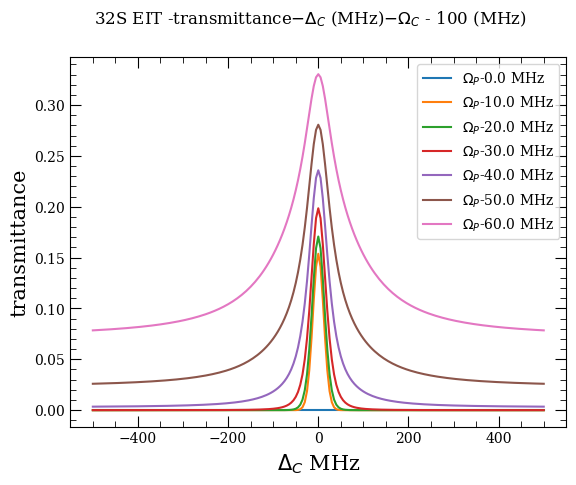

In [564]:
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
for i in range(len(transmittance_list)):  
    transmittance_list[0] = np.zeros(len(transmittance_list[0]))
    plt.plot(deltalist,transmittance_list[i],label="$\Omega_{P}$-"+str(omegaP_list[i]/1E6)+" MHz") 
    #plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xlabel("$\Delta_C$"+" MHz", fontdict = font2)     
    plt.ylabel(r"transmittance", fontdict = font2)
plt.suptitle('32S EIT -' + r"transmittance" + "$ - \Delta_C$ (MHz)"+"$ - \Omega_C$ - 100 (MHz)", fontdict = font2) 
#    plt.yticks([])  
#plt.xlim(-5,5)  
#plt.xlim(-10,10)
# check imaginary path of chi  
plt.legend()
plt.show()

In [565]:
def EIT_signal(omegaP,omegaC): 
    deltaP =0   
    deltaC = 0    
    omega = 0 
    omegaP = omegaP*10**6 
    omegaC = omegaC*10**6
    res=[]
    for deltaC in deltalist:
        H = 1/2*Qobj([[0,omegaP,0,0],[omegaP,-2*(deltaP)*10**6,omegaC,0]
               ,[0,omegaC,-2*(deltaP+deltaC)*10**6,omega],
                       [0,0,omega,-2*(deltaP+deltaC+deltaRF)*10**6]])
        rho_ss = steadystate(H,collapse)  
        res.append(expect(sig_12.dag(),rho_ss)) 
    Efield = E_from_Rabi(omegaP,abs(dipmat12))   
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]  
    transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]  
    return transmittance


In [581]:
test = EIT_signal(60,120)

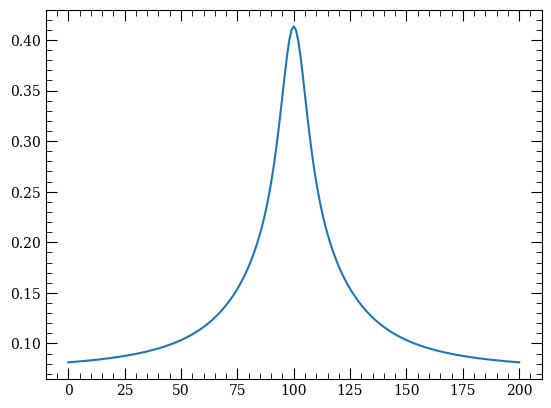

In [582]:
plt.plot(test)

In [568]:
omegaC = np.linspace(120,0,61)
omegaP = np.linspace(0,120.0,61) 
print(omegaP,omegaC)

[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120.] [120. 118. 116. 114. 112. 110. 108. 106. 104. 102. 100.  98.  96.  94.
  92.  90.  88.  86.  84.  82.  80.  78.  76.  74.  72.  70.  68.  66.
  64.  62.  60.  58.  56.  54.  52.  50.  48.  46.  44.  42.  40.  38.
  36.  34.  32.  30.  28.  26.  24.  22.  20.  18.  16.  14.  12.  10.
   8.   6.   4.   2.   0.]


In [569]:
for j in tqdm(omegaC): 
    for i in omegaP: 
        df = pd.DataFrame(EIT_signal(i,j),columns = ['transmittance'])  
        df.to_csv("E:\EIT\EIT_qutip\EIT_no_ex_field_32s_transmit\omegaP"+str(i)+"_omegaC"+str(j)+".csv", index=False)

100%|██████████| 61/61 [42:54<00:00, 42.20s/it]


In [504]:
def peak_cut(omegaP,omegaC):  
    path='E:\EIT\EIT_qutip\EIT_no_ex_field_32s_transmit\omegaP'+str(omegaP)+'_omegaC'+str(omegaC)+'.csv'  
    df = pd.read_csv(path) 
    yval = df['transmittance'].values 
    return yval

In [570]:
peak_hieght_fit = [[np.max(peak_cut(i,j))-np.min(peak_cut(i,j)) for i in omegaP] for j in tqdm(omegaC)]

100%|██████████| 61/61 [00:28<00:00,  2.12it/s]


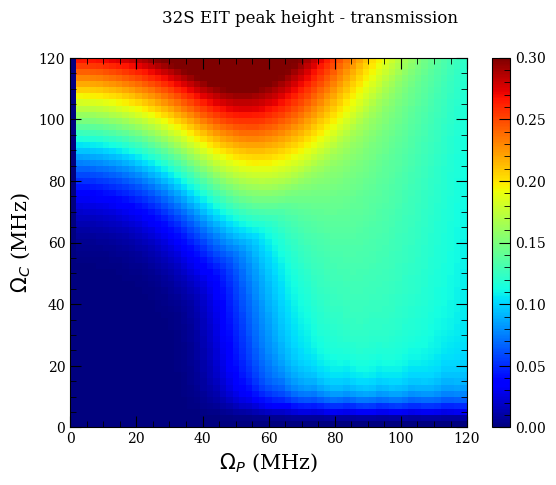

In [580]:
plt.imshow(peak_hieght_fit,vmin=0.00,origin='upper', extent=[0,120,0,120], vmax=0.30, cmap='jet', aspect='auto')  
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
plt.suptitle('32S EIT peak height - transmission', fontdict = font1)
plt.xlabel("$\Omega_P$"+" (MHz)", fontdict = font2)
plt.ylabel("$\Omega_C$"+" (MHz)", fontdict = font2)
plt.colorbar()

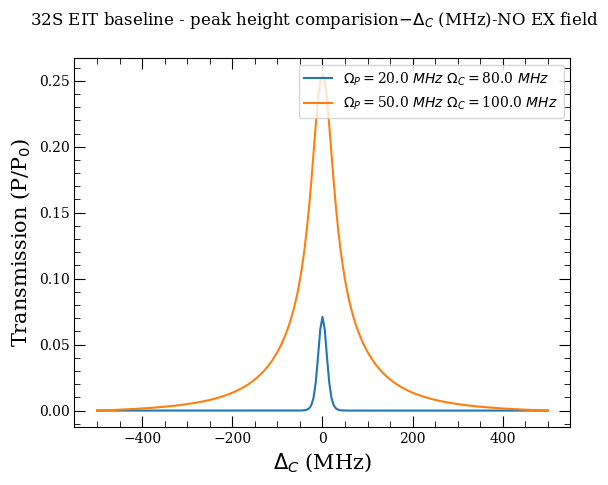

In [592]:
peak1_P,peak1_C = 20.0,80.0
peak2_P,peak2_C = 50.0,100.0
base_shift1 = peak_cut(peak1_P,peak1_C) - np.min(peak_cut(peak1_P,peak1_C)) 
base_shift2 = peak_cut(peak2_P,peak2_C) - np.min(peak_cut(peak2_P,peak2_C))
plt.plot(deltalist,base_shift1,'-',label="$\Omega_{P}=$" + str(peak1_P)+"$\ MHz\ \Omega_{C}=$" +str(peak1_C)+"$\ MHz$")    
plt.plot(deltalist,base_shift2,'-',label="$\Omega_{P}=$" + str(peak2_P)+"$\ MHz\ \Omega_{C}=$" +str(peak2_C)+"$\ MHz$")
plt.suptitle('32S EIT baseline - ' + "peak height comparision" +  "$- \Delta_C$ (MHz)"+"-NO EX field")
plt.xlabel("$\Delta_C$"+" (MHz)", fontdict = font2)     
plt.ylabel('Transmission (P/P$_{0}$)', fontdict = font2) 
plt.legend()

In [ ]:
# create list of delta_p values
deltalist = np.linspace(-500,500,201)
# empty list to save results
chi = [] # susceptibility

In [593]:
def EIT_im_x(omegaP,omegaC): 
    deltaP =0   
    deltaC = 0    
    omega = 0 
    omegaP = omegaP*10**6 
    omegaC = omegaC*10**6
    res=[]
    for deltaC in deltalist:
        H = 1/2*Qobj([[0,omegaP,0,0],[omegaP,-2*(deltaP)*10**6,omegaC,0]
               ,[0,omegaC,-2*(deltaP+deltaC)*10**6,omega],
                       [0,0,omega,-2*(deltaP+deltaC+deltaRF)*10**6]])
        rho_ss = steadystate(H,collapse)  
        res.append(expect(sig_12.dag(),rho_ss)) 
    Efield = E_from_Rabi(omegaP,abs(dipmat12))   
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]   
    return -1*np.imag(chi)

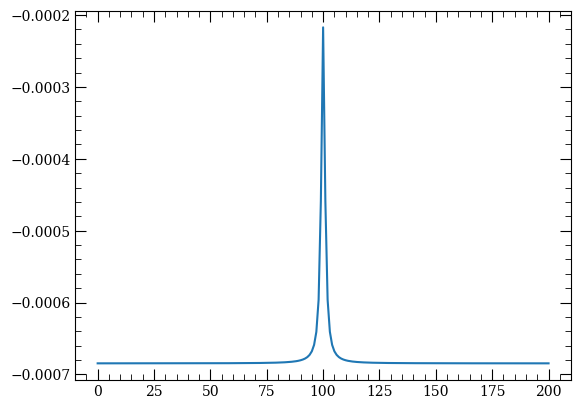

In [594]:
plt.plot(EIT_im_x(0.1,10))

In [616]:
omegaC = np.linspace(70,0,71)
omegaP = np.arange(0,300,5)/100  
print(omegaC,omegaP)

[70. 69. 68. 67. 66. 65. 64. 63. 62. 61. 60. 59. 58. 57. 56. 55. 54. 53.
 52. 51. 50. 49. 48. 47. 46. 45. 44. 43. 42. 41. 40. 39. 38. 37. 36. 35.
 34. 33. 32. 31. 30. 29. 28. 27. 26. 25. 24. 23. 22. 21. 20. 19. 18. 17.
 16. 15. 14. 13. 12. 11. 10.  9.  8.  7.  6.  5.  4.  3.  2.  1.  0.] [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05
 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75
 2.8  2.85 2.9  2.95]


In [617]:
omegaC = np.linspace(70,0,71)
omegaP = np.arange(0,300,5)/100 
for j in tqdm(omegaC): 
    for i in omegaP:  
        df = pd.DataFrame(EIT_im_x(i,j),columns = ['im_x'])  
        df.to_csv("E:\EIT\EIT_qutip\EIT_no_ex_field_32s_im_x\omegaP"+str(i)+"_omegaC"+str(j)+".csv", index=False)

100%|██████████| 71/71 [53:04<00:00, 44.85s/it]


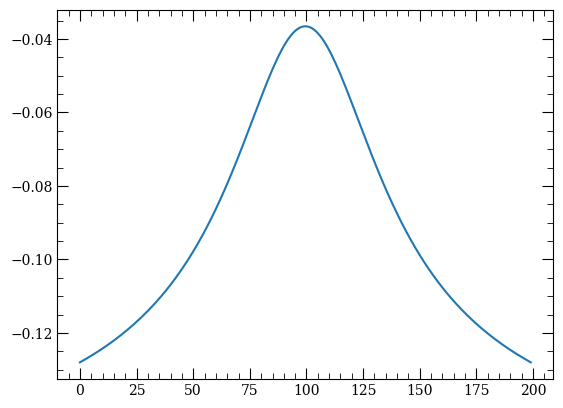

In [17]:
plt.plot(yval)

In [620]:
def peak_cut(omegaP,omegaC):  
    path='E:\EIT\EIT_qutip\EIT_no_ex_field_32s_im_x\omegaP'+str(omegaP)+'_omegaC'+str(omegaC)+'.csv'  
    df = pd.read_csv(path) 
    yval = df['im_x'].values 
    return yval

In [621]:
peak_cut(0.1,9.0)

array([-0.00068461, -0.00068461, -0.00068461, -0.00068461, -0.00068461,
       -0.00068461, -0.00068461, -0.0006846 , -0.0006846 , -0.0006846 ,
       -0.0006846 , -0.0006846 , -0.0006846 , -0.0006846 , -0.0006846 ,
       -0.0006846 , -0.0006846 , -0.0006846 , -0.00068459, -0.00068459,
       -0.00068459, -0.00068459, -0.00068459, -0.00068459, -0.00068459,
       -0.00068459, -0.00068458, -0.00068458, -0.00068458, -0.00068458,
       -0.00068458, -0.00068458, -0.00068457, -0.00068457, -0.00068457,
       -0.00068457, -0.00068457, -0.00068456, -0.00068456, -0.00068456,
       -0.00068455, -0.00068455, -0.00068455, -0.00068455, -0.00068454,
       -0.00068454, -0.00068453, -0.00068453, -0.00068453, -0.00068452,
       -0.00068452, -0.00068451, -0.00068451, -0.0006845 , -0.00068449,
       -0.00068449, -0.00068448, -0.00068447, -0.00068447, -0.00068446,
       -0.00068445, -0.00068444, -0.00068443, -0.00068442, -0.0006844 ,
       -0.00068439, -0.00068437, -0.00068436, -0.00068434, -0.00

In [623]:
omegaC = np.linspace(70,0,71)
omegaP = np.arange(0,300,5)/100 
O_p, O_c = np.meshgrid(omegaP, omegaC)

In [624]:
peak_hieght_fit = [[np.max(peak_cut(i,j))-np.min(peak_cut(i,j)) for i in omegaP] for j in tqdm(omegaC) ] 

100%|██████████| 71/71 [00:32<00:00,  2.20it/s]


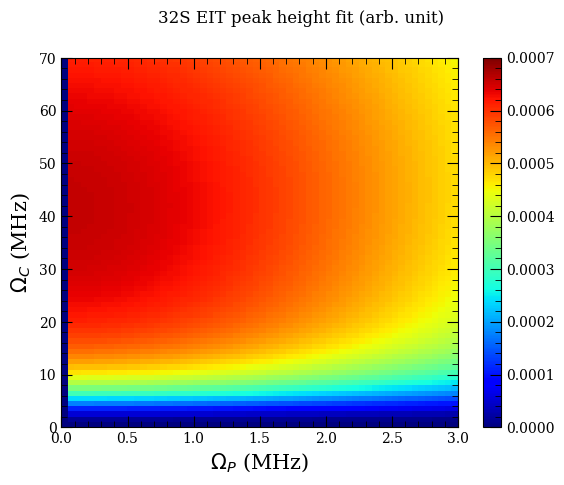

In [629]:
plt.imshow(peak_hieght_fit,vmin=0.00,origin='upper', extent=[0,3.0,0,70], vmax=0.0007, cmap='jet', aspect='auto')  
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
plt.suptitle('32S EIT peak height fit (arb. unit)', fontdict = font1)
plt.xlabel("$\Omega_P$"+" (MHz)", fontdict = font2)
plt.ylabel("$\Omega_C$"+" (MHz)", fontdict = font2)
plt.colorbar()

In [634]:
omegaC = np.linspace(75,0,76)
omegaP = np.arange(0,1500,25)/100 
print(omegaC,omegaP)

[75. 74. 73. 72. 71. 70. 69. 68. 67. 66. 65. 64. 63. 62. 61. 60. 59. 58.
 57. 56. 55. 54. 53. 52. 51. 50. 49. 48. 47. 46. 45. 44. 43. 42. 41. 40.
 39. 38. 37. 36. 35. 34. 33. 32. 31. 30. 29. 28. 27. 26. 25. 24. 23. 22.
 21. 20. 19. 18. 17. 16. 15. 14. 13. 12. 11. 10.  9.  8.  7.  6.  5.  4.
  3.  2.  1.  0.] [ 0.    0.25  0.5   0.75  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75
  3.    3.25  3.5   3.75  4.    4.25  4.5   4.75  5.    5.25  5.5   5.75
  6.    6.25  6.5   6.75  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75
  9.    9.25  9.5   9.75 10.   10.25 10.5  10.75 11.   11.25 11.5  11.75
 12.   12.25 12.5  12.75 13.   13.25 13.5  13.75 14.   14.25 14.5  14.75]


In [635]:
for j in tqdm(omegaC): 
    for i in omegaP:  
        df = pd.DataFrame(EIT_im_x(i,j),columns = ['im_x'])  
        df.to_csv("E:\EIT\EIT_qutip\EIT_no_ex_field_32s_im_x2\omegaP"+str(i)+"_omegaC"+str(j)+".csv", index=False)

100%|██████████| 76/76 [53:17<00:00, 42.08s/it]


In [638]:
def peak_cut(omegaP,omegaC):  
    path='E:\EIT\EIT_qutip\EIT_no_ex_field_32s_im_x2\omegaP'+str(omegaP)+'_omegaC'+str(omegaC)+'.csv'  
    df = pd.read_csv(path) 
    yval = df['im_x'].values 
    return yval

In [640]:
peak_hieght_fit = [[np.max(peak_cut(i,j))-np.min(peak_cut(i,j)) for i in omegaP] for j in tqdm(omegaC) ] 



























































































































































100%|██████████| 76/76 [00:23<00:00,  3.27it/s]


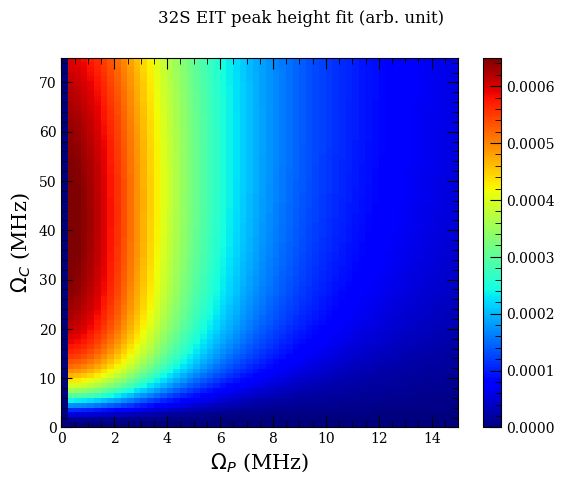

In [644]:
plt.imshow(peak_hieght_fit,vmin=0.00,origin='upper', extent=[0,15.0,0,75], vmax=0.00065, cmap='jet', aspect='auto')  
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
plt.suptitle('32S EIT peak height fit (arb. unit)', fontdict = font1)
plt.xlabel("$\Omega_P$"+" (MHz)", fontdict = font2)
plt.ylabel("$\Omega_C$"+" (MHz)", fontdict = font2)
plt.colorbar()

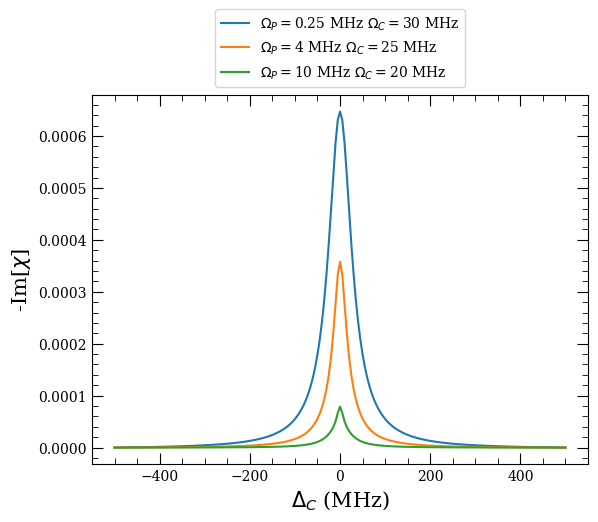

In [664]:
peak1_P,peak1_C = 0.25,30.0
peak2_P,peak2_C = 4.0,25.0 
peak3_P,peak3_C = 10.0,20.0
base_shift1 = peak_cut(peak1_P,peak1_C) - np.min(peak_cut(peak1_P,peak1_C)) 
base_shift2 = peak_cut(peak2_P,peak2_C) - np.min(peak_cut(peak2_P,peak2_C)) 
base_shift3 = peak_cut(peak3_P,peak3_C) - np.min(peak_cut(peak3_P,peak3_C))
plt.plot(deltalist,base_shift1,'-',label="$\Omega_{P}=$" + str(peak1_P)+" MHz $\Omega_{C}=$" +str(int(peak1_C))+" MHz")    
plt.plot(deltalist,base_shift2,'-',label="$\Omega_{P}=$" + str(int(peak2_P))+" MHz $\Omega_{C}=$" +str(int(peak2_C))+" MHz") 
plt.plot(deltalist,base_shift3,'-',label="$\Omega_{P}=$" + str(int(peak3_P))+" MHz $\Omega_{C}=$" +str(int(peak3_C))+" MHz")
#plt.suptitle('32S EIT baseline - ' + "peak height comparision" +  "$- \Delta_C$ (MHz)"+"-NO EX field")
plt.xlabel("$\Delta_C$"+" (MHz)", fontdict = font2)     
plt.ylabel('-Im[$\chi$]', fontdict = font2)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25),ncol=1,)

In [666]:
base_shift1.max() 

0.0006469992984116253

: 

In [23]:
peak_max = np.max(peak_hieght_fit ) ;peak_max

0.09152828572439664

In [24]:
np.unravel_index(np.argmax(peak_max, axis=None), peak_max.shape)

()

In [25]:
max_position = np.unravel_index(np.argmax(peak_hieght_fit), np.array(peak_hieght_fit).shape);max_position

(69, 7)

In [26]:
peak_hieght_fit[69][7]

0.09152828572439664

In [27]:
omegaC[69]

15.5

In [28]:
omegaP[7]

3.5

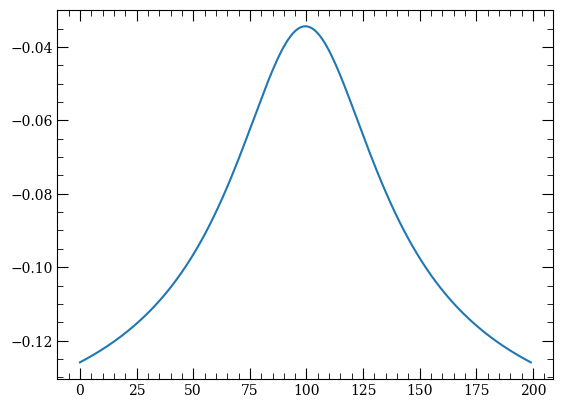

In [29]:
plt.plot(peak_cut(3.5,15.5))

In [122]:
lambda_trans[0],lambda_trans[1]

(7.802415056628226e-07, 4.821001280638597e-07)

## Add doppler broaddenning 

In [140]:
len(v_list)

363

In [149]:
# Define the levels and atomic projection operators
one, two, three = [basis(3,i) for i in range(3)]

In [150]:
from scipy.constants import Planck,epsilon_0,Boltzmann

In [151]:
# Define the levels and atomic projection operators
sig_11 = one * one.dag()
sig_22 = two * two.dag()
sig_33 = three * three.dag() 
sig_12 = one * two.dag()  
sig_13 = one * three.dag() 
sig_23 = two * three.dag()  

In [152]:
sig_12

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = False
Qobj data =
[[0. 1. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

In [153]:
H = 1/2*Qobj([[0,omegaP,0],[omegaP,-2*deltaP_prime,omegaC]
            ,[0,omegaC,-2*(deltaP_prime+deltaC_prime)]]) ;H

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0.00000000e+00 5.00000000e-02 0.00000000e+00]
 [5.00000000e-02 1.85816451e+03 5.00000000e-01]
 [0.00000000e+00 5.00000000e-01 1.27842267e+09]]

In [167]:
#collapse operators 
c_12 = -np.sqrt(gamma[0][1])*sig_12 # 1-2 coherence decay  
#c_21 = -np.sqrt(gamma[0][1])*sig_21
c_13 = -np.sqrt(gamma[0][2])*sig_13 # 1-3 coherence decay  
#c_31 = -np.sqrt(gamma[0][2])*sig_31 # 1-3 coherence decay  
c_23 = -np.sqrt(gamma[1][2])*sig_23 # 2-3 coherence decay 
#c_32 = -np.sqrt(gamma[1][2])*sig_32 # 2-3 coherence decay 
#transitions decay rate  
c_11 = np.sqrt(gamma[1][1])*sig_22
c_22 = np.sqrt(gamma[2][2])*sig_33 -  np.sqrt(gamma[1][1])*sig_22
c_33 =  -  np.sqrt(gamma[2][2])*sig_33
#check define collapse operator
collapse = [c_11,c_22,c_33,c_12,c_13,c_23]

In [168]:
deltaP =0  
omega =0  
deltalist = np.linspace(-10,10,100)
def EIT_peak(omegaP,omegaC):   
    chi=[]
    for deltaC in deltalist:
        H = 1/2*Qobj([[0,omegaP,0],[omegaP,-2*deltaP ,omegaC]
            ,[0,omegaC,-2*(deltaP + deltaC)]])
        rho_ss = steadystate(H,collapse)
        chi.append(expect(sig_12,rho_ss))
    return np.imag(chi)

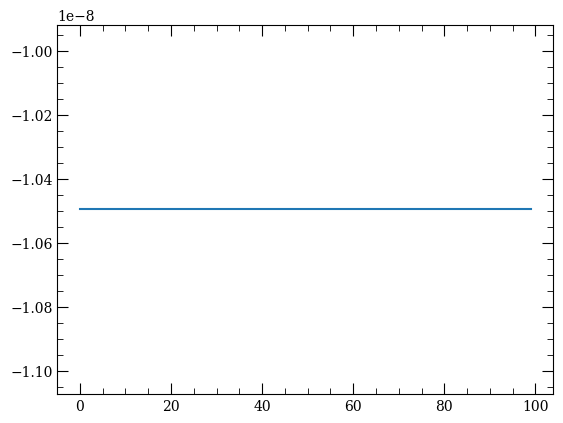

In [169]:
plt.plot(EIT_peak(1,10))

In [164]:
deltaC_list = np.linspace(-12,12,100)
deltaP =0 
deltaRF =0    
omega =0 
omegaP = 0.1 # Rabi freq. for probe
omegaC = 1 # Rabi freq. for control  
rho_12_dopler_avg = [] # list for collecting density 12  
rho_delta = []
for deltaC in tqdm(deltaC_list):    
    chi_im = [] 
    rho_12_v =[]
    for v in v_list: 
        deltaP_prime = deltaP + 2*v*1E-6 /lambda_trans[0]
        deltaC_prime = deltaC - 2*v*1E-6/lambda_trans[1]  
        H = 1/2*Qobj([[0,omegaP,0],[omegaP,-2*deltaP_prime,omegaC]
            ,[0,omegaC,-2*(deltaP_prime+deltaC_prime)]])
        rho_ss = steadystate(H,collapse) 
        rho_v =np.imag(expect(sig_12,rho_ss))     
        rho_12_v.append(rho_v*exp(-(v/u)**2))
    rho_12_dopler_avg = integrate.simpson(rho_12_v,v_list)
    rho_delta.append(rho_12_dopler_avg) 

100%|██████████| 100/100 [01:27<00:00,  1.14it/s]


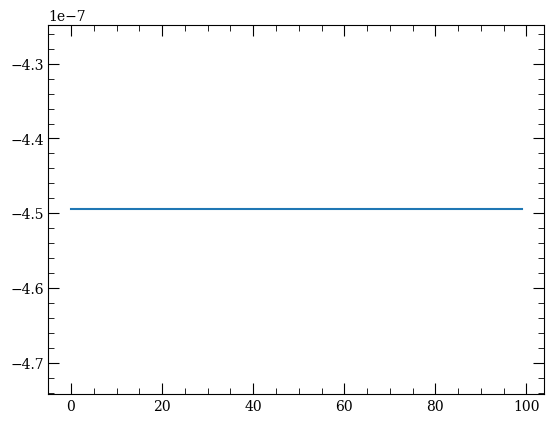

In [165]:
plt.plot(rho_delta)

In [162]:
deltaP =0  
omega =0  
deltalist = np.linspace(-10,10,100)
def EIT_peak(omegaP,omegaC):   
    chi=[]
    for deltaC in deltalist: 
        deltaC_prime = deltaC - 2*v*1E-6/lambda_trans[1] 
        H = 1/2*Qobj([[0,omegaP,0],[omegaP,-2*deltaC_prime,omegaC]
            ,[0,omegaC,-2*(deltaP_prime+deltaC_prime)]])
        rho_ss = steadystate(H,collapse)
        chi.append(expect(sig_12,rho_ss))
    return np.imag(chi)

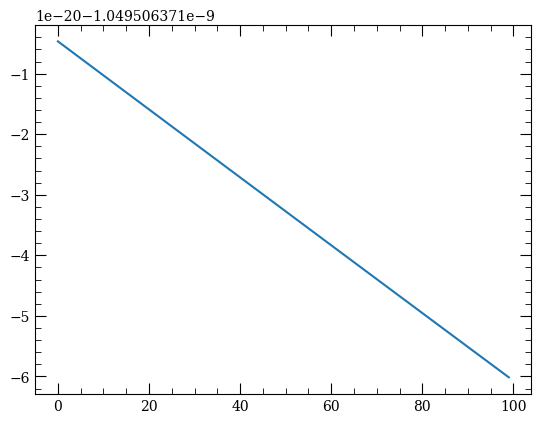

In [163]:
plt.plot(EIT_peak(0.1,10))

### EIT